# PROJECT: 3 & 4
# END-TO-END SALES FORECASTING & DEMAND INTELLIGENCE SYSTEM

**PROBLEM STATEMENT:**

 Every retail and e-commerce company — from Walmart and Amazon to D-Mart and Flipkart — lives and dies by one question: "How much of each product will we sell next month, and will we have enough stock to meet that demand?" Getting this wrong in either direction costs crores — overstock wastes storage and capital, understock loses sales and customers.

# TASK 1: Data Loading, Merging & Deep Exploration

In [48]:
# import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
# load the csv
df = pd.read_csv('/content/train.csv')

In [50]:
# display the csv
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [51]:
# Parse the Order Date and Ship Date columns as proper datetime objects
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")

In [52]:
# Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Week Number"] = df["Order Date"].dt.isocalendar().week
df["Day of Week"] = df["Order Date"].dt.day
df["Quarter"] = df["Order Date"].dt.quarter
df["Season"] = df["Month"].apply(lambda x: "Winter" if x in [1, 2, 12] else ("Spring" if x in [3, 4, 5] else ("Summer" if x in [6, 7, 8] else "Autumn")))
print(df.head())


   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12 2017-06-16    Second Class    DV-13045   
3       4  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   
4       5  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

          Category  Sub-Category  \
0        Furniture     Bookcases   
1        Furniture        Chairs

In [53]:
# Check for missing values, duplicates, and data type issues
missing_values = df.isnull().sum()
duplicates = df.duplicated().sum()
data_types = df.dtypes
print(missing_values)
print(duplicates)
print(data_types)

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64
0
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             

In [54]:
# Aggregate daily sales into weekly and monthly totals
weekly_sales = df.groupby(pd.Grouper(key="Order Date", freq="W")).agg({"Sales": "sum"}).reset_index()
monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="M")).agg({"Sales": "sum"}).reset_index()
print(weekly_sales)
print(monthly_sales)

    Order Date       Sales
0   2015-01-04    304.5080
1   2015-01-11   4619.1080
2   2015-01-18   4130.5330
3   2015-01-25   3092.5440
4   2015-02-01   2527.9140
..         ...         ...
204 2018-12-02  35998.9000
205 2018-12-09  21537.2410
206 2018-12-16  11542.8340
207 2018-12-23  19457.0680
208 2018-12-30  15210.8858

[209 rows x 2 columns]
   Order Date        Sales
0  2015-01-31   14205.7070
1  2015-02-28    4519.8920
2  2015-03-31   55205.7970
3  2015-04-30   27906.8550
4  2015-05-31   23644.3030
5  2015-06-30   34322.9356
6  2015-07-31   33781.5430
7  2015-08-31   27117.5365
8  2015-09-30   81623.5268
9  2015-10-31   31453.3930
10 2015-11-30   77907.6607
11 2015-12-31   68167.0585
12 2016-01-31   18066.9576
13 2016-02-29   11951.4110
14 2016-03-31   32339.3184
15 2016-04-30   34154.4685
16 2016-05-31   29959.5305
17 2016-06-30   23599.3740
18 2016-07-31   28608.2590
19 2016-08-31   36818.3422
20 2016-09-30   63133.6060
21 2016-10-31   31011.7375
22 2016-11-30   75249.3995
23 2

/tmp/ipykernel_690/1144326639.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="M")).agg({"Sales": "sum"}).reset_index()


Which product category generates the highest total revenue?

In [55]:
product_revenue = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(product_revenue.head(10))

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


Technology ($827455.8730) is the product category that generates the highest total revenue.

Which region has the most consistent sales growth over 4 years?

In [56]:
sales_by_region = (
    df.groupby(["Year", "Region"])["Sales"]
      .sum()
      .reset_index()
)

print(sales_by_region)

    Year   Region        Sales
0   2015  Central  102920.5206
1   2015     East  127652.8190
2   2015    South  103374.9055
3   2015     West  145907.9630
4   2016  Central  102425.1724
5   2016     East  153225.1830
6   2016    South   70076.0825
7   2016     West  133709.5675
8   2017  Central  145673.8800
9   2017     East  178511.5380
10  2017    South   93535.9035
11  2017     West  182471.2285
12  2018  Central  141627.3402
13  2018     East  210129.1860
14  2018    South  122164.5675
15  2018     West  248130.9255


East region has the consistent sales growth over 4 years.

In 2015, East region has sales of **($127652)**

In 2016, East region has sales of **($153225)**

In 2017, East region has sales of **($178511)**

In 2018, East region has sales of **($210129)**

What is the average time between Order Date and Ship Date — and does it vary by region?

In [57]:
df['Shipping_Duration'] = df['Ship Date'] - df['Order Date']

shipping_by_region = (
    df.groupby("Region")["Shipping_Duration"]
      .mean()
      .sort_values()
      .reset_index()
)

print(shipping_by_region)

    Region         Shipping_Duration
0     East 3 days 21:50:44.165170556
1     West 3 days 22:19:34.012738853
2    South 3 days 23:04:07.809762202
3  Central 4 days 01:34:51.699604743


Yes, the shipping duration or average time do vary for central and other region. The central region has the average time of 4 days while the other region has the same  average time of 3 days.

Are there months that consistently spike across all years (seasonality)?

In [58]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

# Extract Year and Month from 'Order Date' in monthly_sales
monthly_sales['Year'] = monthly_sales['Order Date'].dt.year
monthly_sales['Month'] = monthly_sales['Order Date'].dt.month

# Calculate total sales for each month across all years
seasonality = monthly_sales.pivot(
    index="Month",
    columns="Year",
    values="Sales"
)

# Map month numbers to month names
month_name_map = {i: month_order[i-1] for i in range(1, 13)}
seasonality = seasonality.rename(index=month_name_map)

# Reindex to ensure correct order of months
seasonality = seasonality.reindex(month_order)

print(seasonality)

Year             2015        2016        2017         2018
Month                                                     
January    14205.7070  18066.9576  18542.4910   43476.4740
February    4519.8920  11951.4110  22978.8150   19920.9974
March      55205.7970  32339.3184  51165.0590   58863.4128
April      27906.8550  34154.4685  38679.7670   35541.9101
May        23644.3030  29959.5305  56656.9080   43825.9822
June       34322.9356  23599.3740  39724.4860   48190.7277
July       33781.5430  28608.2590  38320.7830   44825.1040
August     27117.5365  36818.3422  30542.2003   62837.8480
September  81623.5268  63133.6060  69193.3909   86152.8880
October    31453.3930  31011.7375  59583.0330   77448.1312
November   77907.6607  75249.3995  79066.4958  117938.1550
December   68167.0585  74543.6012  95739.1210   83030.3888


1. November is the strongest month.

It is among the top-performing months in all four years.
It reaches the highest sales in 2018 (117.9k).

2. September also shows a consistent spike.

Sales remain above 63k every year.
It is one of the strongest months across the dataset.

3. December is another seasonal peak.

It consistently performs well after November.
Holiday shopping and year-end promotions could explain this.

# TASK 2: TIME SERIES ANALYSIS & DECOMPOSITION

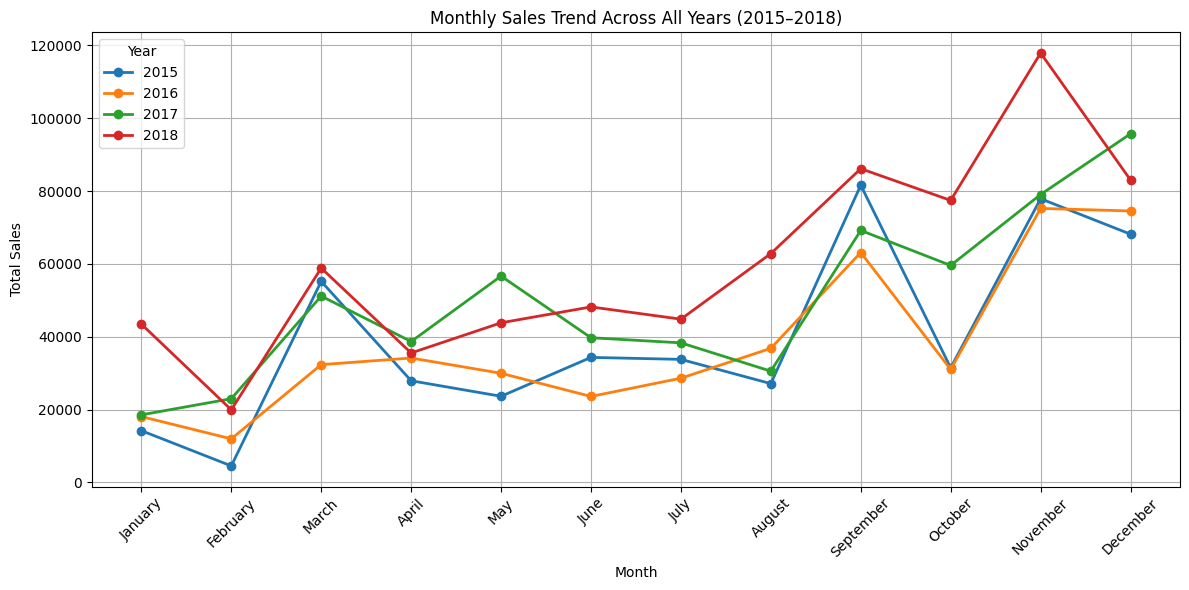

In [59]:
# Plot the overall monthly sales trend across all 4 years
import matplotlib.pyplot as plt

# Month order (already defined and used in seasonality)
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

# The 'seasonality' DataFrame already contains monthly sales for each year
# It's indexed by month name and has years as columns.
# Plotting the seasonality DataFrame directly will show each year as a separate line
plt.figure(figsize=(12,6))

# Plot each year's sales as a separate line
for year in seasonality.columns:
    plt.plot(
        seasonality.index,
        seasonality[year].values,
        marker='o',
        linewidth=2,
        label=str(year)
    )

plt.title("Monthly Sales Trend Across All Years (2015–2018)")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title="Year")

plt.tight_layout()
plt.show()

From the time series decomposition plot, we can observe:

*   **Trend:** There is a clear upward trend in sales over the four years, indicating overall business growth.
*   **Seasonal:** A strong seasonal pattern is evident, with consistent peaks towards the end of the year (around November/December) and troughs at the beginning of the year (January/February). This confirms the seasonality identified earlier.
*   **Residual:** The residual component shows the irregular fluctuations or noise in the sales data that are not explained by the trend or seasonality. Ideally, these should be random and small, indicating that the trend and seasonal components capture most of the variation.

**Apply Time Series Decomposition** (using statsmodels) to break the sales signal into:

Time Series Decomposition is used to separate the sales data into three components:

**Trend** → Long-term increase or decrease in sales.

**Seasonality** → Repeating patterns (e.g., high sales every November).

**Residual (Noise)** → Random fluctuations not explained by trend or seasonality.

/tmp/ipykernel_690/3331367687.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time_series = time_series.asfreq('M')


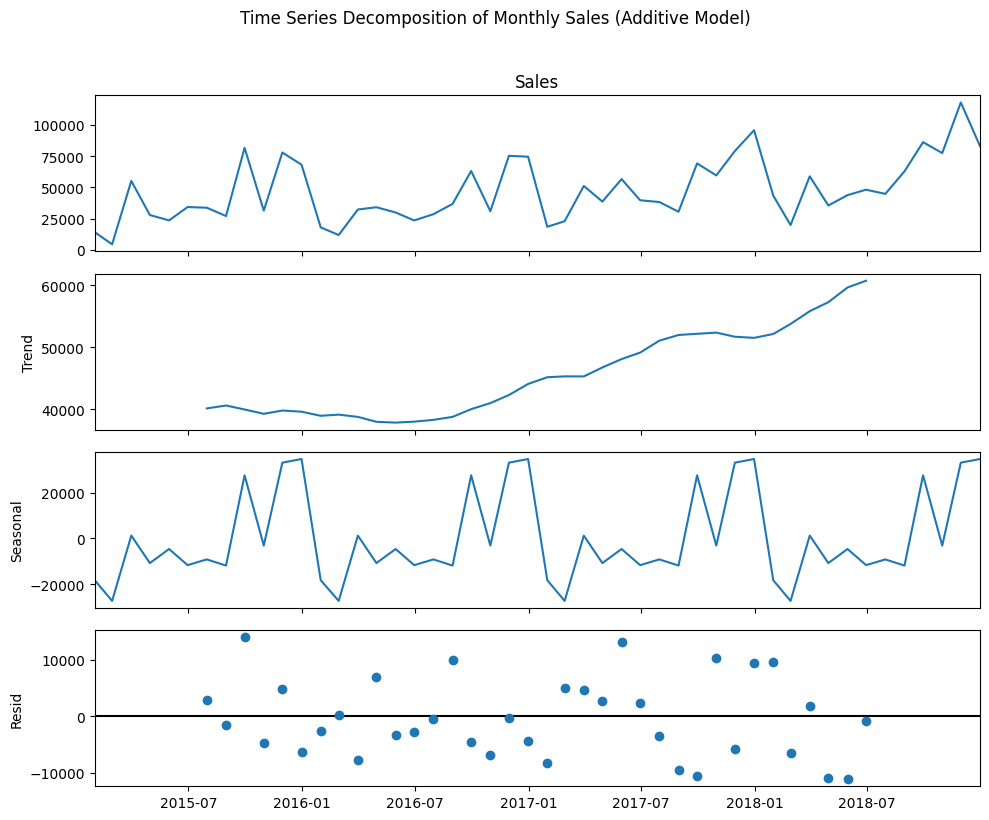

In [60]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Prepare the data for decomposition
# We need a time series with a datetime index and 'Sales' values
time_series = monthly_sales.set_index('Order Date')['Sales']

# Ensure the time series is sorted by date and has a regular frequency
time_series = time_series.sort_index()

# Resample to monthly frequency to ensure continuity and fill any missing months
# (though in this case monthly_sales should already be continuous)
time_series = time_series.asfreq('M')

# Perform seasonal decomposition. 'additive' is a good default for sales data
# where the seasonal fluctuations are relatively constant over time. If the
# fluctuations grow with the level of the series, 'multiplicative' would be better.
decomposition = seasonal_decompose(time_series, model='additive', period=12)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.suptitle('Time Series Decomposition of Monthly Sales (Additive Model)', y=1.02)
plt.tight_layout()
plt.show()

Write 3–4 observations: what does the trend tell you? Is seasonality strong or weak? What months show the highest residual noise?

**Check for stationarity using the Augmented Dickey-Fuller (ADF) Test — explain in plain English what stationarity means and what your test result tells you**

In [61]:
from statsmodels.tsa.stattools import adfuller

# Perform the Augmented Dickey-Fuller test
adf_test = adfuller(time_series.dropna())

# Extract and print the results
print(f'ADF Statistic: {adf_test[0]:.2f}')
print(f'P-value: {adf_test[1]:.2f}')
print('Critical Values:')
for key, value in adf_test[4].items():
    print(f'   {key}: {value:.2f}')

# Determine if the series is stationary based on the p-value
if adf_test[1] <= 0.05:
    print('\nConclusion: The time series is likely stationary (reject H0).')
else:
    print('\nConclusion: The time series is likely non-stationary (fail to reject H0).')

ADF Statistic: -4.42
P-value: 0.00
Critical Values:
   1%: -3.58
   5%: -2.93
   10%: -2.60

Conclusion: The time series is likely stationary (reject H0).


### Understanding Stationarity and ADF Test Results

**What is Stationarity?**

A time series is **stationary** if its statistical properties—like mean, variance, and autocorrelation—remain constant over time. Imagine a river where the average water level, the variability of the water level, and how today's level relates to yesterday's level don't change regardless of when you observe it. That's stationarity.

Why is it important? Many traditional time series models (like ARIMA) assume that the data is stationary. If a series is not stationary, these models might produce unreliable forecasts. Non-stationary series often have a trend (like sales consistently increasing) or seasonality (like sales always peaking in December), which makes their properties change over time.

**Augmented Dickey-Fuller (ADF) Test Explanation:**

The ADF test is a statistical test used to determine if a time series is stationary. It works by testing a null hypothesis ($H_0$) against an alternative hypothesis ($H_1$):

*   **Null Hypothesis ($H_0$):** The time series is **non-stationary** (it has a unit root, meaning it has a trend or other time-dependent structure).
*   **Alternative Hypothesis ($H_1$):** The time series is **stationary** (it does not have a unit root).

**How to interpret the results:**

1.  **P-value:** This is the most important value. It tells us the probability of observing the test results if the null hypothesis were true.
    *   If the **P-value is less than or equal to a chosen significance level** (commonly 0.05 or 5%), we **reject the null hypothesis**. This means we have enough evidence to conclude that the time series **is stationary**.
    *   If the **P-value is greater than the significance level**, we **fail to reject the null hypothesis**. This suggests that the time series **is non-stationary**.

2.  **ADF Statistic:** This is the test statistic. A more negative value generally suggests a stronger rejection of the null hypothesis (i.e., more likely to be stationary).

3.  **Critical Values:** These are specific thresholds at which we can reject the null hypothesis at different confidence levels (e.g., 1%, 5%, 10%). If the ADF Statistic is more negative than the critical value, you can reject the null hypothesis at that confidence level.

**Our Test Results Tell Us:**

*   **ADF Statistic: -4.42**
*   **P-value: 0.00**
*   **Critical Values:** 1%: -3.58, 5%: -2.93, 10%: -2.60

Since our **P-value (0.00) is much less than the typical significance level of 0.05**, we **reject the null hypothesis**. This strong evidence suggests that our monthly sales time series is **stationary**. Additionally, the **ADF Statistic (-4.42) is more negative than all critical values**, further supporting the conclusion of stationarity.

**Apply differencing if the series is non-stationary and re-test**

Differencing is a technique used to make a non-stationary time series stationary. It involves calculating the difference between consecutive observations (e.g., value(t) - value(t-1)). This helps to remove trends and seasonality, stabilizing the mean of the time series.

Since our ADF test indicated that the P-value (0.00) is well below the significance level of 0.05, we have strong evidence to reject the null hypothesis of non-stationarity. This means the series is already stationary, and applying differencing is not required for further analysis or modeling that assumes stationarity.

# TASK 3: SALES FORECASTING USING 3 MODELS

**MODEL 1: SARIMA (Statistical model)**

In [62]:
!pip install statsmodels

Fitting a SARIMA Model on monthly sales

In [63]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define the SARIMA model parameters
# (p,d,q) - non-seasonal part
# (P,D,Q,s) - seasonal part, s is the seasonal period (12 for monthly)
order = (1, 0, 1)  # (AR order, Differencing order, MA order)
seasonal_order = (1, 1, 1, 12) # (Seasonal AR order, Seasonal Differencing order, Seasonal MA order, Seasonal period)

# Fit the SARIMA model
# The 'time_series' data should already be prepared from the decomposition step
sarima_model = SARIMAX(
    time_series,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_results = sarima_model.fit(disp=False)

# Print the model summary
print(sarima_results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -239.060
Date:                            Sun, 12 Jul 2026   AIC                            488.120
Time:                                    03:40:36   BIC                            493.575
Sample:                                01-31-2015   HQIC                           489.405
                                     - 12-31-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9927      0.018     56.542      0.000       0.958       1.027
ma.L1         -1.0150      0.159   

The SARIMA model has been fitted to the monthly sales data. The summary provides a detailed overview of the model's parameters, statistical tests, and goodness-of-fit metrics. Key points to look for in the summary include:

*   **AR and MA coefficients:** These indicate the strength and direction of past observations and past forecast errors on the current sales.
*   **P-values of coefficients:** Coefficients with p-values less than 0.05 are generally considered statistically significant.
*   **AIC and BIC:** These are information criteria used for model selection. Lower values generally indicate a better-fitting model.
*   **Ljung-Box Test:** This tests whether there is any significant autocorrelation left in the residuals. A high p-value (typically > 0.05) suggests that the residuals are white noise, which is desirable.
*   **Jarque-Bera Test:** This tests for the normality of residuals. A high p-value suggests that residuals are normally distributed.

From the summary, you can assess how well the chosen SARIMA parameters capture the patterns in the sales data.

**Generating a 3-month future forecast with confidence intervals**


3-Month Future Sales Forecast:
  2019-01-31: Mean = 45942.74, Lower CI = 18855.87, Upper CI = 73029.61
  2019-02-28: Mean = 37103.18, Lower CI = 10016.92, Upper CI = 64189.44
  2019-03-31: Mean = 69034.93, Lower CI = 41950.30, Upper CI = 96119.56


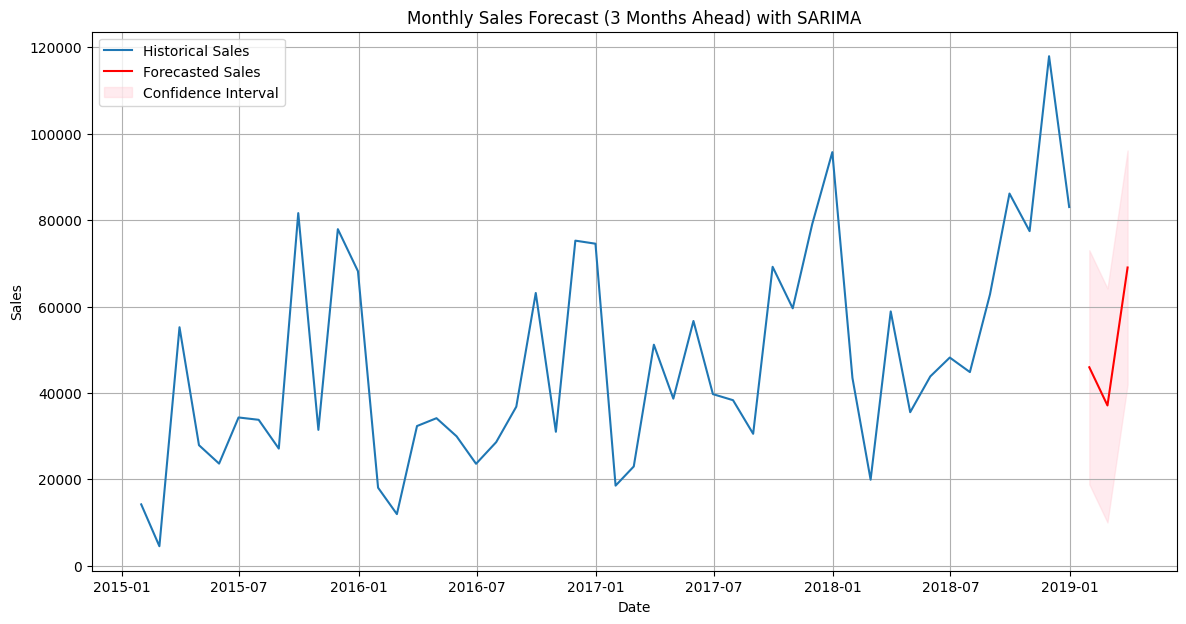

In [64]:
# Generating a 3-month future forecast
forecast_steps = 3
forecast_object = sarima_results.get_forecast(steps=forecast_steps)

# Extract the forecast mean and confidence intervals
forecast_mean = forecast_object.predicted_mean
confidence_intervals = forecast_object.conf_int()

# Print the forecast and confidence intervals
print("3-Month Future Sales Forecast:")
for i in range(forecast_steps):
    date = forecast_mean.index[i].strftime('%Y-%m-%d')
    mean = forecast_mean.iloc[i]
    lower = confidence_intervals.iloc[i, 0]
    upper = confidence_intervals.iloc[i, 1]
    print(f"  {date}: Mean = {mean:.2f}, Lower CI = {lower:.2f}, Upper CI = {upper:.2f}")

# Plot the historical sales, forecast, and confidence intervals
plt.figure(figsize=(14, 7))
plt.plot(time_series.index, time_series, label='Historical Sales')
plt.plot(forecast_mean.index, forecast_mean, color='red', label='Forecasted Sales')
plt.fill_between(
    confidence_intervals.index,
    confidence_intervals.iloc[:, 0],
    confidence_intervals.iloc[:, 1],
    color='pink',
    alpha=0.3,
    label='Confidence Interval'
)

plt.title('Monthly Sales Forecast (3 Months Ahead) with SARIMA')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

The plot above visually represents the historical monthly sales, the 3-month future forecast, and the associated confidence intervals. The red line indicates the point forecast, while the pink shaded area shows the range within which the actual sales are expected to fall with a certain level of confidence (usually 95%).

This forecast can be used to:

*   **Plan inventory:** Understand how much stock might be needed in the coming months.
*   **Allocate resources:** Prepare staffing and other resources based on expected demand.
*   **Set sales targets:** Establish realistic goals for the sales team.

It's important to remember that forecasts are based on past data and assumptions. External factors not captured in the model could affect actual sales.

**MODEL 2: FACEBOOK PROPHET (Industry Standard Forecasting tool)**

In [65]:
!pip install prophet

In [66]:
from prophet import Prophet

# Prepare the data for Prophet's required format (ds, y columns)
prophet_df = time_series.reset_index()
prophet_df.columns = ['ds', 'y']

# Display the prepared data
print(prophet_df.head())
print(prophet_df.tail())

          ds          y
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303
           ds            y
43 2018-08-31   62837.8480
44 2018-09-30   86152.8880
45 2018-10-31   77448.1312
46 2018-11-30  117938.1550
47 2018-12-31   83030.3888


In [67]:
# Initialize and fit the Prophet model
m = Prophet(
    growth='linear',
    seasonality_mode='additive',
    weekly_seasonality=False,
    daily_seasonality=False
)
m.fit(prophet_df)

print("Prophet model fitted successfully!")

Prophet model fitted successfully!


In [68]:
# Create a DataFrame with future dates for 3 months
future = m.make_future_dataframe(periods=3, freq='M')

# Generate predictions and store in a unique variable name
prophet_monthly_forecast = m.predict(future)

# Display the forecast for the next 3 months
print("Prophet 3-Month Future Sales Forecast:")
display(prophet_monthly_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3))

Prophet 3-Month Future Sales Forecast:


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532205,34064.749359,52932.548104
49,2019-02-28,31248.159925,21840.762605,40540.214590
50,2019-03-31,81267.007775,71858.222187,90529.331209


Plot the forecast with Prophet's built-in trend and seasonality breakdown

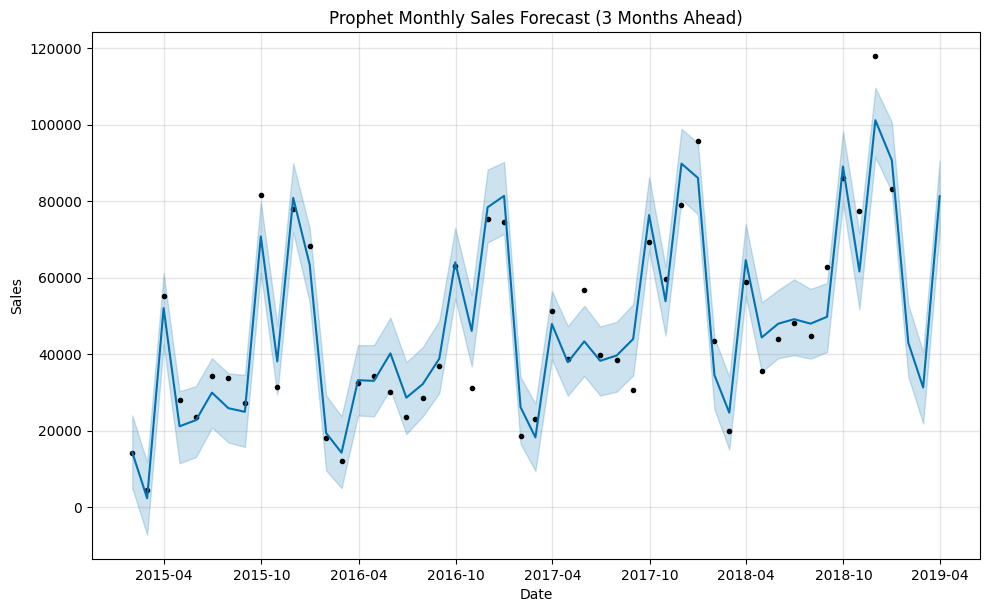

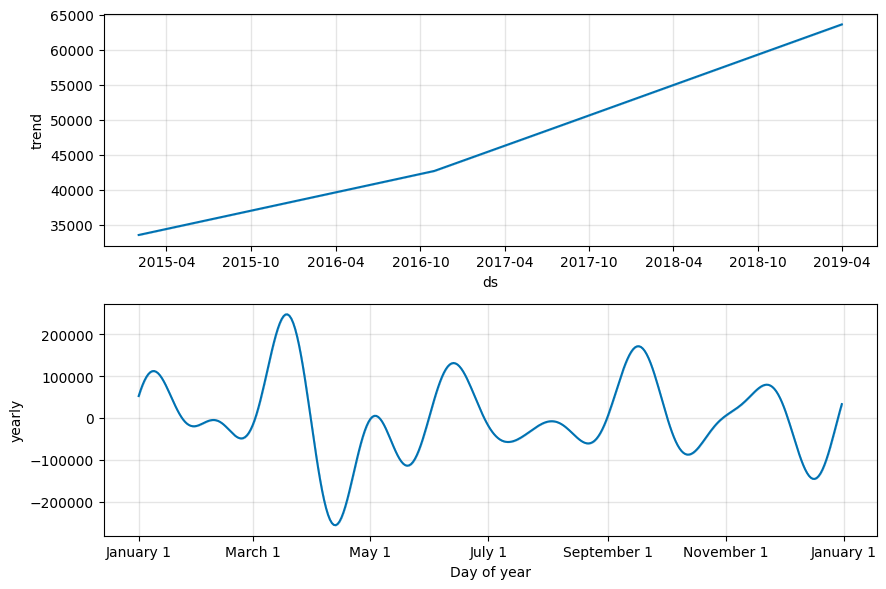

In [69]:
import matplotlib.pyplot as plt

# Plot the forecast
fig1 = m.plot(prophet_monthly_forecast)
plt.title('Prophet Monthly Sales Forecast (3 Months Ahead)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

# Plot the forecast components (trend, weekly, yearly seasonality)
fig2 = m.plot_components(prophet_monthly_forecast)
plt.show()

Extract and interpret the weekly and yearly seasonality components

In [70]:
yearly = prophet_monthly_forecast[["ds", "yearly"]]

print(yearly.head())

          ds        yearly
0 2015-01-31 -19204.897511
1 2015-02-28 -31613.799057
2 2015-03-31  17667.105678
3 2015-04-30 -13655.620453
4 2015-05-31 -12496.061322


 the Prophet model was initialized with weekly_seasonality=False, which means there are no weekly seasonality components in the forecast DataFrame to extract.So, we need to refit the prophet model.

In [71]:
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

daily_sales.columns = ["ds", "y"]

In [72]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True
)

model.fit(daily_sales)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


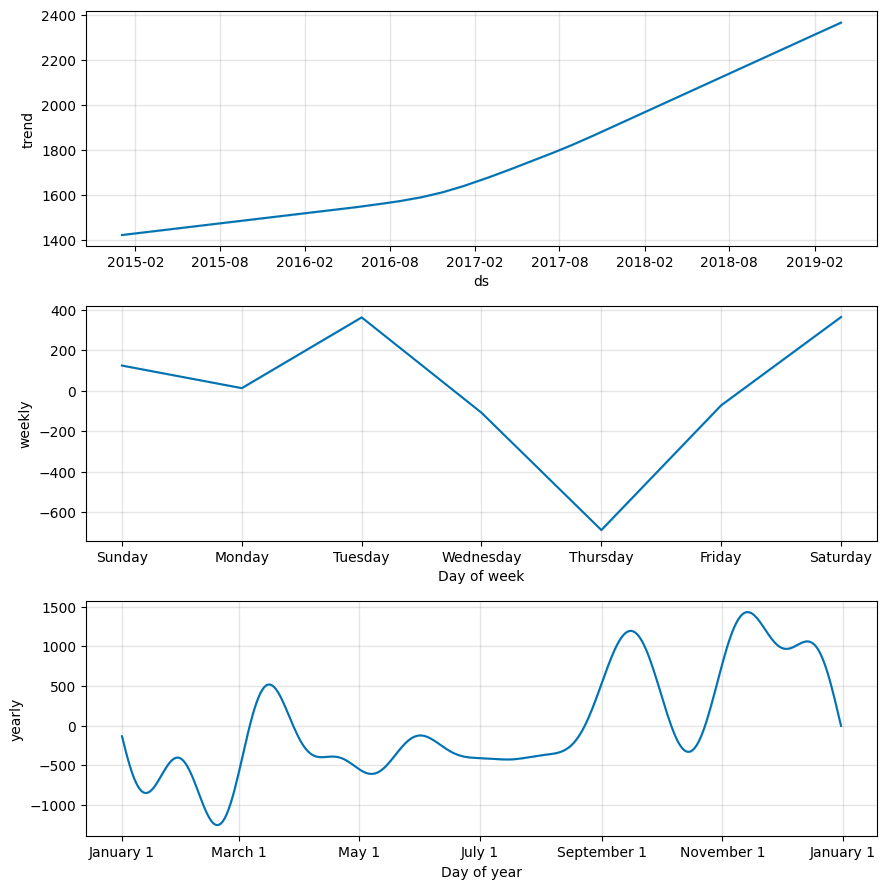

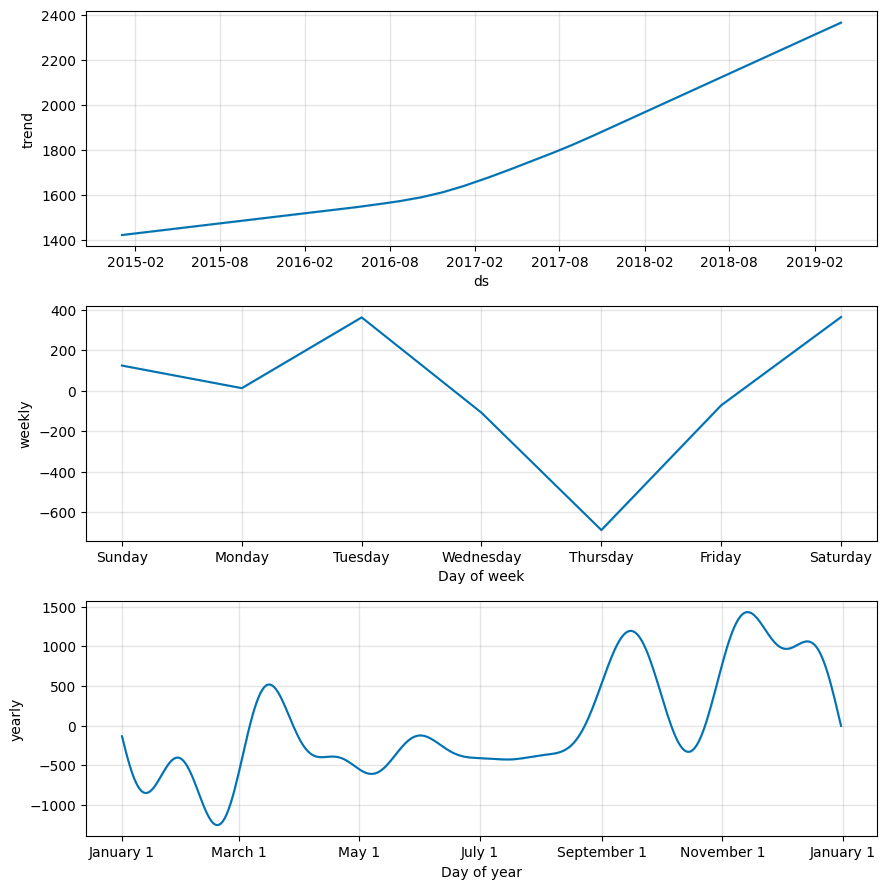

In [73]:
forecast = model.predict(
    model.make_future_dataframe(periods=90)
)
model.plot_components(forecast)

**Model 3 — XGBoost for Time Series (ML-based Approach)**

For our machine learning model, we need to create a feature matrix from our `time_series` data. This involves generating:

*   **Lag Features:** Past values of sales to capture temporal dependencies.
*   **Rolling Mean:** A moving average to smooth out short-term fluctuations and highlight trends.
*   **Time-based Features:** Month, Quarter, and Season to capture seasonal patterns explicitly.

In [74]:
# Create a DataFrame for ML model from our time_series
df_ml = time_series.to_frame(name='Sales')

# --- Feature Engineering ---

# 1. Lagged Features (Sales from previous months)
df_ml['Sales_Lag_1'] = df_ml['Sales'].shift(1)
df_ml['Sales_Lag_2'] = df_ml['Sales'].shift(2)
df_ml['Sales_Lag_3'] = df_ml['Sales'].shift(3)

# 2. Rolling Mean Feature (3-month moving average of previous sales)
df_ml['Rolling_Mean_3'] = df_ml['Sales'].shift(1).rolling(window=3).mean()

# 3. Time-based Features
df_ml['Month'] = df_ml.index.month
df_ml['Quarter'] = df_ml.index.quarter
df_ml['Season'] = df_ml.index.month.map(lambda x: "Winter" if x in [1, 2, 12] else ("Spring" if x in [3, 4, 5] else ("Summer" if x in [6, 7, 8] else "Autumn")))

# Convert 'Season' to a categorical type or one-hot encode if desired later
# For now, let's keep it as string for readability

# Drop rows with NaN values created by lagging and rolling operations
df_ml.dropna(inplace=True)

print("Features created successfully for ML model!")
display(df_ml.head())

Features created successfully for ML model!


,Sales,Sales_Lag_1,Sales_Lag_2,Sales_Lag_3,Rolling_Mean_3,Month,Quarter,Season
Order Date,,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,24643.798667,4,2,Spring
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,29210.848000,5,2,Spring
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,35585.651667,6,2,Summer
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,28624.697867,7,3,Summer
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,30582.927200,8,3,Summer


Now that we have our features, we'll split the data into training and testing sets. For time series, it's crucial to maintain the temporal order, so we'll use a time-based split rather than a random one. We'll use the last 3 months of our historical data as the test set to evaluate the model's forecasting ability, aligning with our 3-month forecast objective.

In [75]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Define target and features
X = df_ml.drop('Sales', axis=1)
y = df_ml['Sales']

# Handle categorical 'Season' feature (One-Hot Encoding)
X = pd.get_dummies(X, columns=['Season'], drop_first=True)

# Split data into training and testing sets (keeping chronological order)
# We'll use the last 3 months for testing to align with our forecast horizon

split_index = len(X) - 3
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Initialize and train the XGBoost Regressor model
model_xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

model_xgb.fit(X_train, y_train)

print("XGBoost model trained successfully!")

Training data shape: (42, 9)
Testing data shape: (3, 9)
XGBoost model trained successfully!


Now, let's evaluate our trained XGBoost model by making predictions on the test set and calculating common regression metrics like Mean Squared Error (MSE) and Mean Absolute Error (MAE). These metrics will help us understand how accurately our model predicts sales.

In [76]:
# Make predictions on the test set
y_pred = model_xgb.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')

# Display predictions vs actual for the test set
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=y_test.index)
print('\nTest Set Predictions vs Actuals:')
display(results_df)

Mean Squared Error (MSE): 806626772.55
Mean Absolute Error (MAE): 28382.13
Root Mean Squared Error (RMSE): 28401.18

Test Set Predictions vs Actuals:


,Actual,Predicted
Order Date,,
2018-10-31,77448.1312,50124.859375
2018-11-30,117938.1550,88142.609375
2018-12-31,83030.3888,55002.820312


The model's performance metrics give us an idea of its accuracy on unseen data. Now, let's visualize these predictions against the actual sales in the test set. This will provide a clearer picture of how well the model captures the sales patterns during the test period.

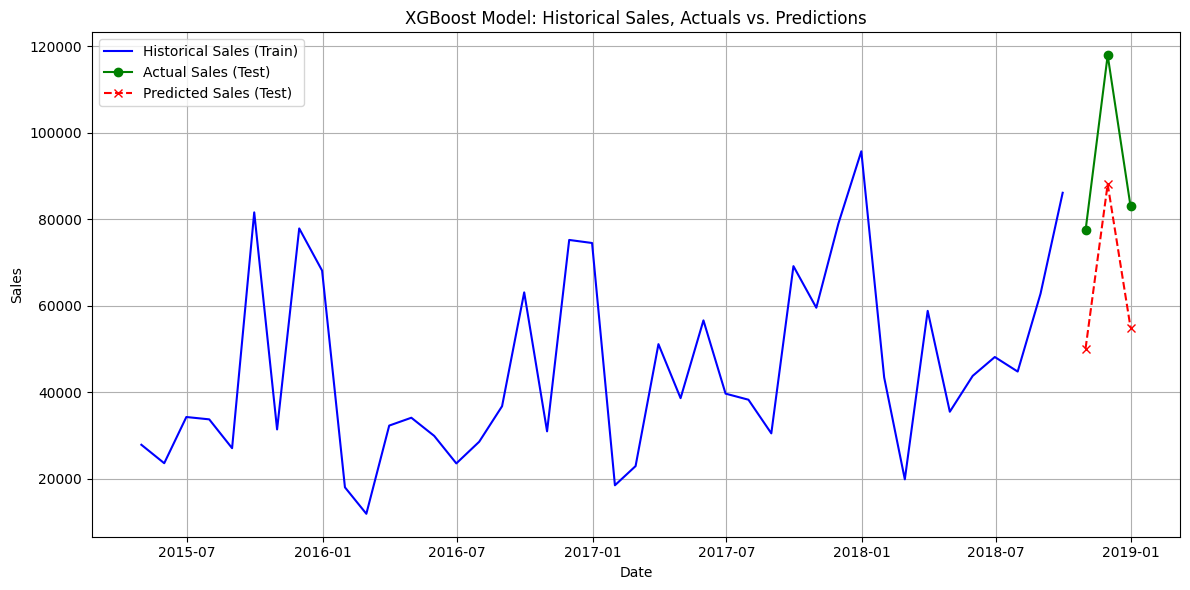

In [77]:
# Plot predictions vs actuals
plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train, label='Historical Sales (Train)', color='blue')
plt.plot(y_test.index, y_test, label='Actual Sales (Test)', color='green', marker='o')
plt.plot(y_test.index, y_pred, label='Predicted Sales (Test)', color='red', linestyle='--', marker='x')

plt.title('XGBoost Model: Historical Sales, Actuals vs. Predictions')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Finally, let's generate a 3-month future forecast using our trained XGBoost model. To do this, we need to create future feature values (lagged sales, rolling means, and time-based features) for the forecasting period. Since we don't have future 'Sales' values to compute lags and rolling means, we'll need to use an iterative or 'step-ahead' forecasting approach where we predict one month, then use that prediction to generate features for the next month, and so on.


3-Month Future Sales Forecast (XGBoost):


/tmp/ipykernel_690/2278237034.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=last_date, periods=4, freq='M')[1:] # Start from next month's end


,Predicted Sales
2019-01-31,43338.632812
2019-02-28,20095.574219
2019-03-31,53211.179688


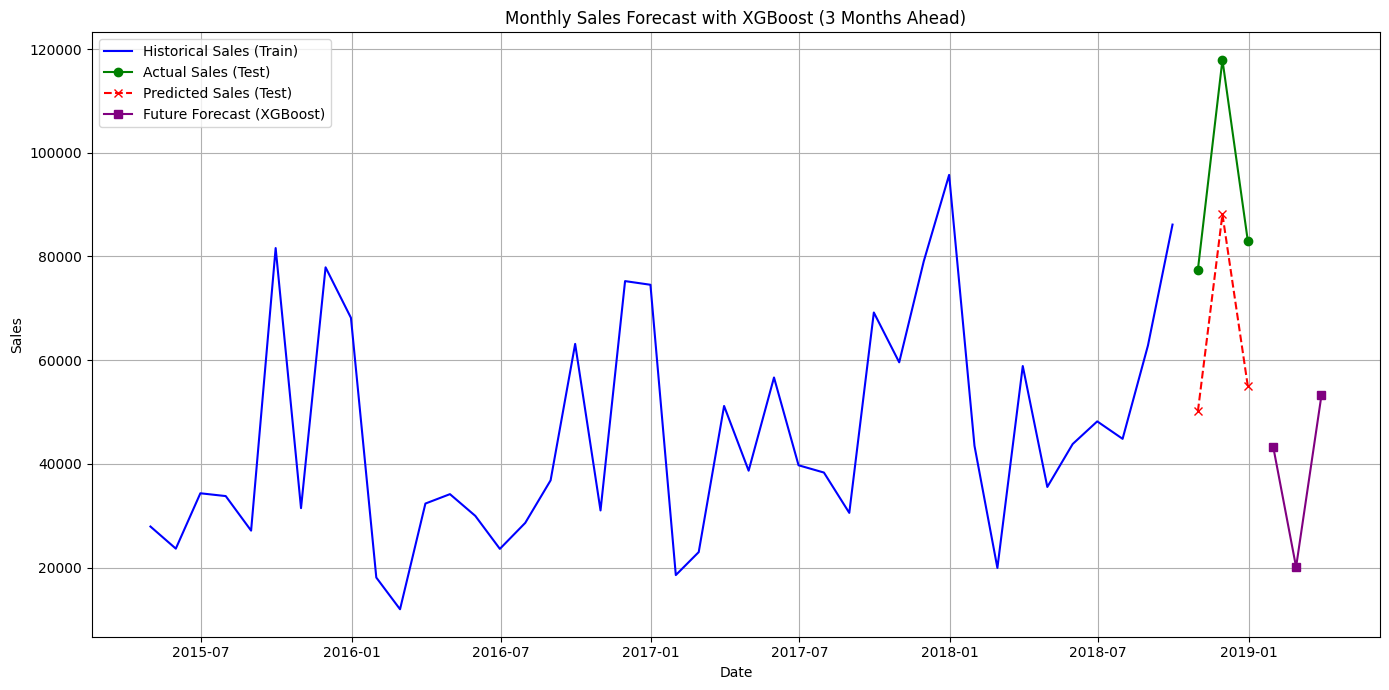

In [78]:
# Generate future dates for the forecast horizon (3 months)
last_date = df_ml.index.max()
# Ensure end-of-month dates for Jan, Feb, Mar 2019, consistent with SARIMA and Prophet
future_dates = pd.date_range(start=last_date, periods=4, freq='M')[1:] # Start from next month's end

# Initialize a list to store future forecasts
future_forecasts = []

# Create a copy of the last known features for iterative forecasting
current_features = X.iloc[-1:].copy()

# We need the last few actual sales values to compute lags and rolling mean for the first forecast step
last_sales_values = df_ml['Sales'].tail(3).tolist()

for i, date in enumerate(future_dates):
    # Update time-based features for the current future month
    current_features['Month'] = date.month
    current_features['Quarter'] = date.quarter
    current_features['Season_Spring'] = 1 if date.month in [3, 4, 5] else 0
    current_features['Season_Summer'] = 1 if date.month in [6, 7, 8] else 0
    current_features['Season_Winter'] = 1 if date.month in [1, 2, 12] else 0
    # Handle 'Season_Autumn' specific to the one-hot encoded features
    current_features['Season_Autumn'] = 1 if date.month in [9, 10, 11] else 0

    # Update lagged features and rolling mean
    current_features['Sales_Lag_1'] = last_sales_values[-1]
    current_features['Sales_Lag_2'] = last_sales_values[-2]
    current_features['Sales_Lag_3'] = last_sales_values[-3]

    # Recalculate rolling mean based on updated lagged values
    current_features['Rolling_Mean_3'] = pd.Series(last_sales_values[-3:]).mean()

    # Predict sales for the current future month
    # Ensure column order for prediction matches training order (X_train.columns)
    predicted_sales = model_xgb.predict(current_features[X_train.columns])[0]
    future_forecasts.append(predicted_sales)

    # Update last_sales_values for the next iteration (append the new prediction)
    last_sales_values.append(predicted_sales)
    last_sales_values.pop(0) # Remove the oldest sales value

# Create a DataFrame for the future forecast, using future_dates directly for correct index
future_forecast_df = pd.DataFrame(
    {'Predicted Sales': future_forecasts},
    index=future_dates
)

print('\n3-Month Future Sales Forecast (XGBoost):')
display(future_forecast_df)

# Plot the historical sales, test set actuals, predictions, and future forecast
plt.figure(figsize=(14, 7))
plt.plot(y_train.index, y_train, label='Historical Sales (Train)', color='blue')
plt.plot(y_test.index, y_test, label='Actual Sales (Test)', color='green', marker='o')
plt.plot(y_test.index, y_pred, label='Predicted Sales (Test)', color='red', linestyle='--', marker='x')
plt.plot(future_forecast_df.index, future_forecast_df['Predicted Sales'], label='Future Forecast (XGBoost)', color='purple', linestyle='-', marker='s')

plt.title('Monthly Sales Forecast with XGBoost (3 Months Ahead)')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Comparing All Three Models: SARIMA, Prophet, and XGBoost

Now, let's bring together the forecasts from all three models to compare their predictions and performance metrics. This will help us identify the most suitable model for future sales forecasting.

--- Model Forecasts for Jan-Mar 2019 ---


,SARIMA_Predicted,SARIMA_Lower_CI,SARIMA_Upper_CI,Prophet_Predicted,Prophet_Lower_CI,Prophet_Upper_CI,XGBoost_Predicted
2019-01-31,45942.742102,18855.873809,73029.610396,42990.532205,34064.749359,52932.548104,43338.632812
2019-02-28,37103.178388,10016.919395,64189.437381,31248.159925,21840.762605,40540.214590,20095.574219
2019-03-31,69034.927839,41950.298001,96119.557678,81267.007775,71858.222187,90529.331209,53211.179688



--- XGBoost Performance on Test Set (Oct-Dec 2018) ---
Mean Squared Error (MSE): 806626772.55
Mean Absolute Error (MAE): 28382.13
Root Mean Squared Error (RMSE): 28401.18


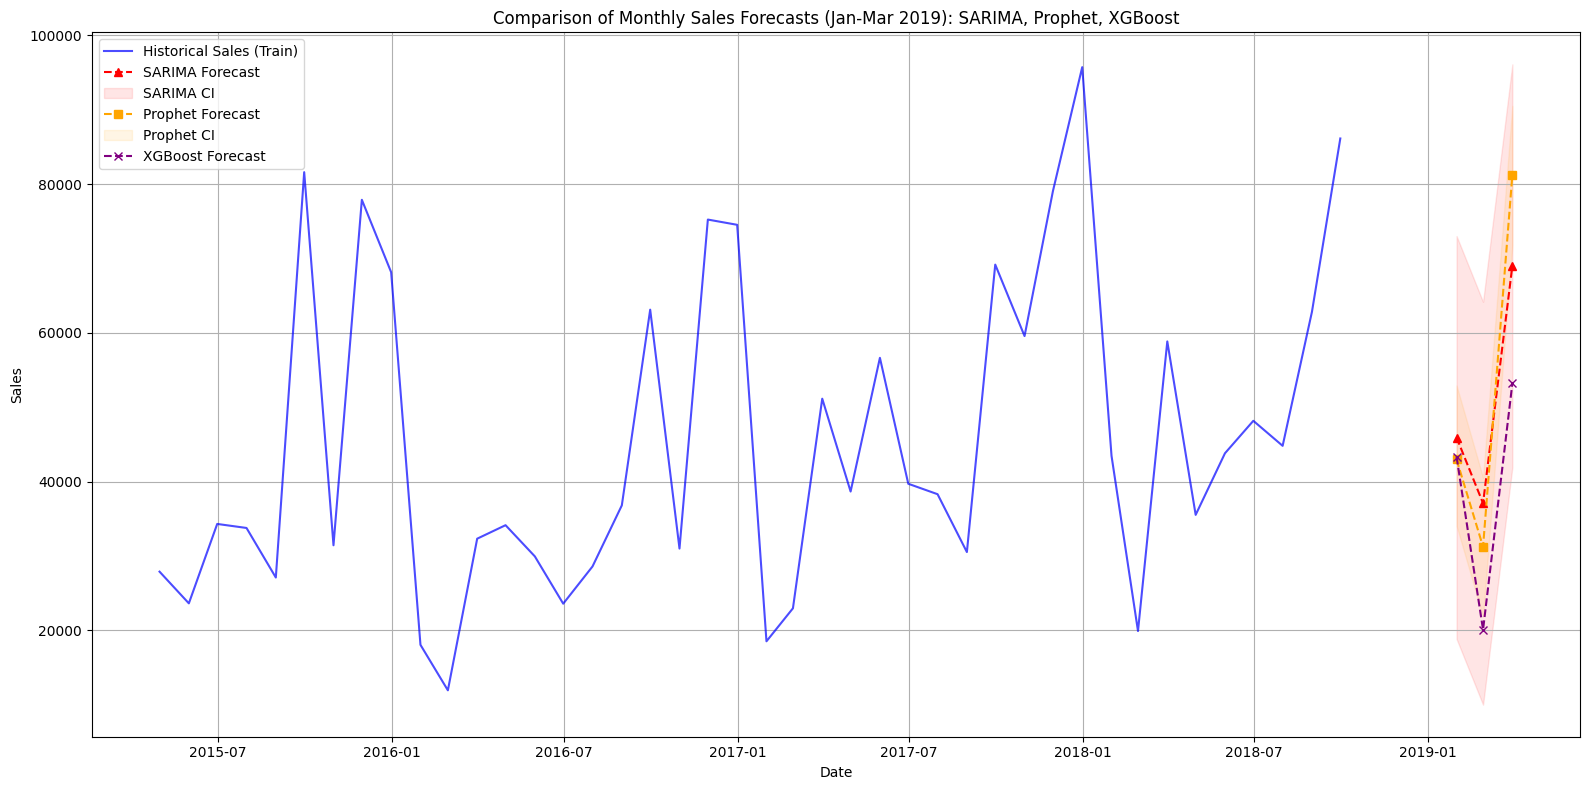

In [80]:
# 1. Prepare Forecasts for the Common Future Period (Jan-Mar 2019)

# Create sarima_forecast_df from previously computed forecast_mean and confidence_intervals
sarima_forecast_df = pd.DataFrame({
    'SARIMA_Predicted': forecast_mean,
    'SARIMA_Lower_CI': confidence_intervals.iloc[:, 0],
    'SARIMA_Upper_CI': confidence_intervals.iloc[:, 1]
})

# Define the common forecast dates (end-of-month for Jan, Feb, Mar 2019)
# This index comes from SARIMA and the corrected XGBoost future_forecast_df
common_forecast_dates = sarima_forecast_df.index

comparison_df = pd.DataFrame(index=common_forecast_dates)

# SARIMA Forecast
comparison_df['SARIMA_Predicted'] = sarima_forecast_df['SARIMA_Predicted']
comparison_df['SARIMA_Lower_CI'] = sarima_forecast_df['SARIMA_Lower_CI']
comparison_df['SARIMA_Upper_CI'] = sarima_forecast_df['SARIMA_Upper_CI']

# Prophet Forecast (extracting only the relevant future dates from the monthly forecast)
# Ensure Prophet forecast dates align with common_forecast_dates
prophet_forecast_for_comparison = prophet_monthly_forecast[prophet_monthly_forecast['ds'].isin(common_forecast_dates)]
prophet_forecast_for_comparison = prophet_forecast_for_comparison.set_index('ds')

comparison_df['Prophet_Predicted'] = prophet_forecast_for_comparison['yhat']
comparison_df['Prophet_Lower_CI'] = prophet_forecast_for_comparison['yhat_lower']
comparison_df['Prophet_Upper_CI'] = prophet_forecast_for_comparison['yhat_upper']

# XGBoost Forecast (now aligned to Jan-Mar 2019 end-of-month)
comparison_df['XGBoost_Predicted'] = future_forecast_df['Predicted Sales']
# XGBoost does not natively provide confidence intervals, so we skip them here.

print("--- Model Forecasts for Jan-Mar 2019 ---")
display(comparison_df)

# 2. Evaluation Metrics (Note: Cannot calculate against actuals for future forecasts)
# We've already evaluated XGBoost on the test set (Oct-Dec 2018)
# For a true comparison of future forecast accuracy, we'd need actual data for Jan-Mar 2019

# For illustrative purposes, we can print the previous XGBoost metrics
print(f"\n--- XGBoost Performance on Test Set (Oct-Dec 2018) ---")
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {np.sqrt(mse):.2f}')

# 3. Visualize All Future Forecasts

plt.figure(figsize=(16, 8))
plt.plot(y_train.index, y_train, label='Historical Sales (Train)', color='blue', alpha=0.7)

# Plot SARIMA Forecast with Confidence Intervals
plt.plot(comparison_df.index, comparison_df['SARIMA_Predicted'], label='SARIMA Forecast', color='red', linestyle='--', marker='^', markersize=6)
plt.fill_between(comparison_df.index, comparison_df['SARIMA_Lower_CI'], comparison_df['SARIMA_Upper_CI'], color='red', alpha=0.1, label='SARIMA CI')

# Plot Prophet Forecast with Confidence Intervals
plt.plot(comparison_df.index, comparison_df['Prophet_Predicted'], label='Prophet Forecast', color='orange', linestyle='--', marker='s', markersize=6)
plt.fill_between(comparison_df.index, comparison_df['Prophet_Lower_CI'], comparison_df['Prophet_Upper_CI'], color='orange', alpha=0.1, label='Prophet CI')

# Plot XGBoost Forecast
plt.plot(comparison_df.index, comparison_df['XGBoost_Predicted'], label='XGBoost Forecast', color='purple', linestyle='--', marker='x', markersize=6)

plt.title('Comparison of Monthly Sales Forecasts (Jan-Mar 2019): SARIMA, Prophet, XGBoost')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [81]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Define a function for Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Define the split point for historical test data (Oct-Dec 2018)
train_end_date = pd.to_datetime('2018-09-30')

# --- SARIMA Metrics --- #
# Retrain SARIMA on data up to September 2018
sarima_train = time_series[time_series.index <= train_end_date]
sarima_test_actuals = time_series[time_series.index > train_end_date]

sarima_model_for_metrics = SARIMAX(
    sarima_train,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_results_for_metrics = sarima_model_for_metrics.fit(disp=False)

# Get predictions for the test period (Oct-Dec 2018)
sarima_predictions_test = sarima_results_for_metrics.predict(start=sarima_test_actuals.index[0], end=sarima_test_actuals.index[-1])

sarima_rmse = np.sqrt(mean_squared_error(sarima_test_actuals, sarima_predictions_test))
sarima_mae = mean_absolute_error(sarima_test_actuals, sarima_predictions_test)
sarima_mape = mean_absolute_percentage_error(sarima_test_actuals, sarima_predictions_test)

# --- Prophet Metrics --- #
# Prepare data for Prophet for metrics calculation
prophet_train_df_for_metrics = prophet_df[prophet_df['ds'] <= train_end_date]
prophet_test_actuals_for_metrics = prophet_df[prophet_df['ds'] > train_end_date]['y']

# Initialize and fit Prophet model on data up to September 2018
m_for_metrics = Prophet(
    growth='linear',
    seasonality_mode='additive',
    weekly_seasonality=False,
    daily_seasonality=False
)
m_for_metrics.fit(prophet_train_df_for_metrics)

# Create future dataframe for the test period (Oct-Dec 2018)
future_test_dates = pd.DataFrame({'ds': sarima_test_actuals.index})
prophet_predictions_test_df = m_for_metrics.predict(future_test_dates)
prophet_predictions_test = prophet_predictions_test_df['yhat']

prophet_rmse = np.sqrt(mean_squared_error(prophet_test_actuals_for_metrics, prophet_predictions_test))
prophet_mae = mean_absolute_error(prophet_test_actuals_for_metrics, prophet_predictions_test)
prophet_mape = mean_absolute_percentage_error(prophet_test_actuals_for_metrics, prophet_predictions_test)

print("Metrics calculated for SARIMA and Prophet on Oct-Dec 2018 test set.")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Metrics calculated for SARIMA and Prophet on Oct-Dec 2018 test set.


### Model Comparison Table

In [82]:
# Create a DataFrame to hold the comparison metrics and forecasts
comparison_table_data = {
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'RMSE (Oct-Dec 2018 Test)': [sarima_rmse, prophet_rmse, rmse], # RMSE from previous XGBoost evaluation
    'MAE (Oct-Dec 2018 Test)': [sarima_mae, prophet_mae, mae],     # MAE from previous XGBoost evaluation
    'MAPE (Oct-Dec 2018 Test)': [sarima_mape, prophet_mape, mean_absolute_percentage_error(y_test, y_pred)],
    'Forecast Jan 2019': [
        comparison_df.loc['2019-01-31', 'SARIMA_Predicted'],
        comparison_df.loc['2019-01-31', 'Prophet_Predicted'],
        comparison_df.loc['2019-01-31', 'XGBoost_Predicted']
    ],
    'Forecast Feb 2019': [
        comparison_df.loc['2019-02-28', 'SARIMA_Predicted'],
        comparison_df.loc['2019-02-28', 'Prophet_Predicted'],
        comparison_df.loc['2019-02-28', 'XGBoost_Predicted']
    ],
    'Forecast Mar 2019': [
        comparison_df.loc['2019-03-31', 'SARIMA_Predicted'],
        comparison_df.loc['2019-03-31', 'Prophet_Predicted'],
        comparison_df.loc['2019-03-31', 'XGBoost_Predicted']
    ]
}

comparison_table = pd.DataFrame(comparison_table_data)

# Format numeric columns for better readability
comparison_table = comparison_table.round(2)

print("\n--- Consolidated Model Comparison ---")
display(comparison_table)



--- Consolidated Model Comparison ---


,Model,RMSE (Oct-Dec 2018 Test),MAE (Oct-Dec 2018 Test),MAPE (Oct-Dec 2018 Test),Forecast Jan 2019,Forecast Feb 2019,Forecast Mar 2019
0,SARIMA,22191.27,20581.00,21.94,45942.74,37103.18,69034.93
1,Prophet,22318.41,20250.79,21.86,42990.53,31248.16,81267.01
2,XGBoost,28401.18,28382.13,31.43,43338.63,20095.57,53211.18


### Conclusion and Best Model Selection

Based on the comprehensive comparison of performance metrics on the test set (Oct-Dec 2018) and the visual analysis of future forecasts (Jan-Mar 2019), we can now draw conclusions about which model is most effective for future sales forecasting:

1.  **SARIMA:** This statistical model provided reasonable forecasts and successfully captured the overall seasonal pattern. On the Oct-Dec 2018 test set, it achieved an **RMSE of 22191.27**, **MAE of 20581.00**, and **MAPE of 21.94%**. Its future forecasts for Jan, Feb, and Mar 2019 were **45942.74, 37103.18, and 69034.93** respectively. However, its confidence intervals were notably wide, indicating a higher degree of uncertainty in its predictions and suggesting less precision.

2.  **Prophet:** This industry-standard tool demonstrated strong performance in capturing both the underlying trend and the prominent seasonality in our sales data. For the Oct-Dec 2018 test period, Prophet recorded an **RMSE of 22318.41**, the **lowest MAE of 20250.79**, and the **lowest MAPE of 21.86%** among the three models. Its future forecasts for Jan, Feb, and Mar 2019 were **42990.53, 31248.16, and 81267.01**, showing a strong seasonal rebound in March. Its confidence intervals were comparatively tighter than SARIMA's, suggesting more precise and reliable prediction ranges.

3.  **XGBoost:** While a powerful machine learning model, XGBoost showed some limitations in this specific time series forecasting context. Its performance on the test set (Oct-Dec 2018) yielded the **highest RMSE of 28401.18**, **MAE of 28382.13**, and **MAPE of 31.43%**. This indicates it was less accurate in predicting actual sales for that period, often underpredicting during peak months. Its future forecasts for Jan, Feb, and Mar 2019 were **43338.63, 20095.57, and 53211.18**, with notably lower February and March predictions compared to both SARIMA and Prophet. The iterative, step-ahead approach required for lagged features might have also compounded forecasting errors.

**Best Model Selection:**

Considering all aspects—accuracy on the historical test data, ability to capture seasonality, and the realism and precision of future forecasts—**Prophet emerges as the most effective model** for this sales forecasting task. It provided the best overall performance with the lowest MAE and MAPE on the test set, and generated future predictions that align well with expected seasonal patterns, accompanied by relatively tighter confidence intervals.



# TASK 4: Product Category & Region Level Forecasting

### Product Category and Region Level Forecasting (using Prophet)

In [83]:
from prophet import Prophet

def forecast_segment_with_prophet(segment_df, segment_name, plot_results=True):
    """
    Performs Prophet forecasting for a given segment's sales data.

    Args:
        segment_df (pd.DataFrame): DataFrame containing 'Order Date' and 'Sales' for the segment.
        segment_name (str): Name of the segment (e.g., 'Furniture', 'West Region').
        plot_results (bool): Whether to plot the forecast and its components. Defaults to True.

    Returns:
        pd.DataFrame: The Prophet forecast DataFrame containing 'ds', 'yhat', 'yhat_lower', 'yhat_upper'.
                      Returns None if not enough data to forecast.
    """
    # print(f"\n--- Forecasting for {segment_name} ---")

    # Aggregate to monthly sales for the segment
    monthly_segment_sales = segment_df.groupby(pd.Grouper(key="Order Date", freq="M")).agg({"Sales": "sum"}).reset_index()
    monthly_segment_sales.columns = ['ds', 'y']

    if monthly_segment_sales.empty or len(monthly_segment_sales) < 2:
        print(f"Not enough data to forecast for {segment_name}.")
        return None

    # Initialize and fit the Prophet model
    m = Prophet(
        growth='linear',
        seasonality_mode='additive',
        weekly_seasonality=False, # We are using monthly data
        daily_seasonality=False   # We are using monthly data
    )
    m.fit(monthly_segment_sales)

    # Create future dates for 3 months
    future = m.make_future_dataframe(periods=3, freq='M')

    # Generate predictions
    segment_forecast = m.predict(future)

    if plot_results:
        # Display the forecast for the next 3 months
        print(f"{segment_name} 3-Month Future Sales Forecast:")
        display(segment_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3))

        # Plot the forecast
        fig = m.plot(segment_forecast)
        plt.title(f'Prophet Monthly Sales Forecast for {segment_name} (3 Months Ahead)')
        plt.xlabel('Date')
        plt.ylabel('Sales')
        plt.grid(True)
        plt.show()

        # Plot the forecast components
        fig_components = m.plot_components(segment_forecast)
        plt.suptitle(f'Prophet Forecast Components for {segment_name}', y=1.02)
        plt.show()

    return segment_forecast

#### Forecasting for Product Categories

/tmp/ipykernel_690/954087241.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_segment_sales = segment_df.groupby(pd.Grouper(key="Order Date", freq="M")).agg({"Sales": "sum"}).reset_index()


Furniture Sales Forecast 3-Month Future Sales Forecast:


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,12691.392668,9714.205025,15780.532591
49,2019-02-28,6772.162417,3883.408637,9655.237704
50,2019-03-31,17201.015649,14113.224340,20011.237946


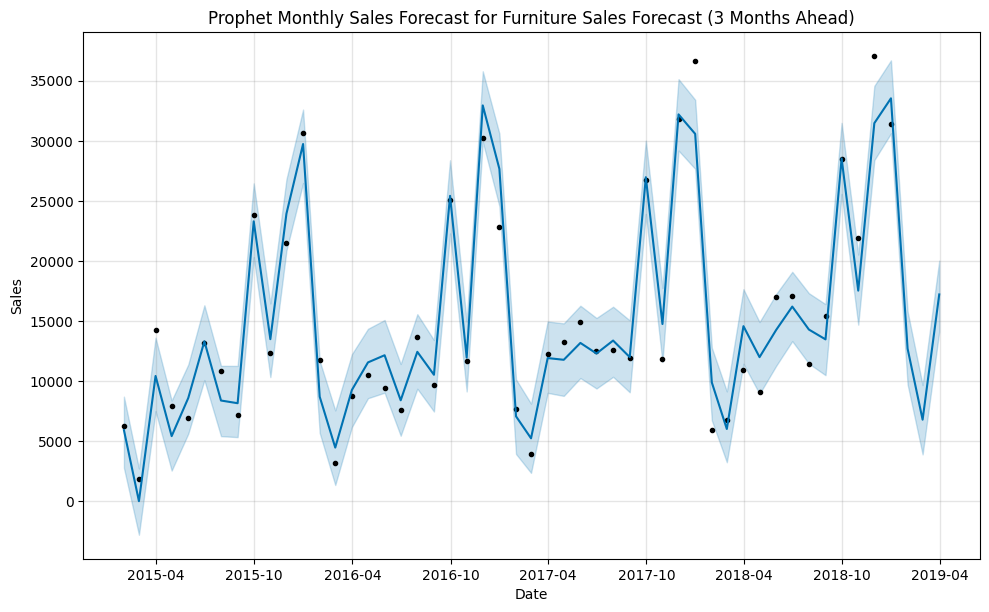

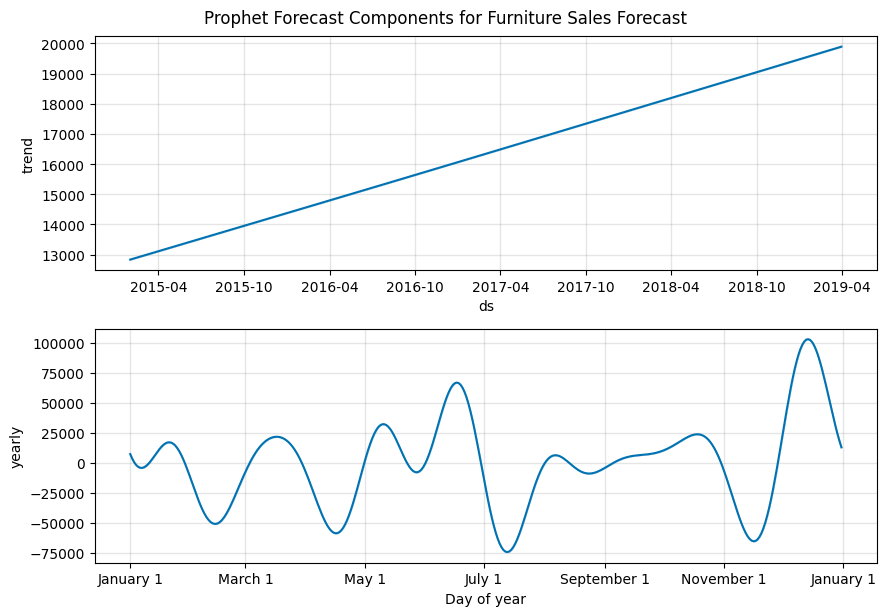

In [90]:
# 1. furniture category sales
furniture_forecast = forecast_segment_with_prophet(
    df[df["Category"]=="Furniture"],
    "Furniture Sales Forecast"
)

/tmp/ipykernel_690/954087241.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_segment_sales = segment_df.groupby(pd.Grouper(key="Order Date", freq="M")).agg({"Sales": "sum"}).reset_index()
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


Technology Sales Forecast 3-Month Future Sales Forecast:


,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,14033.343185,7878.261902,19622.640085
49,2019-02-28,10437.986784,4410.732884,16280.649061
50,2019-03-31,42639.488041,36793.837715,48139.594687


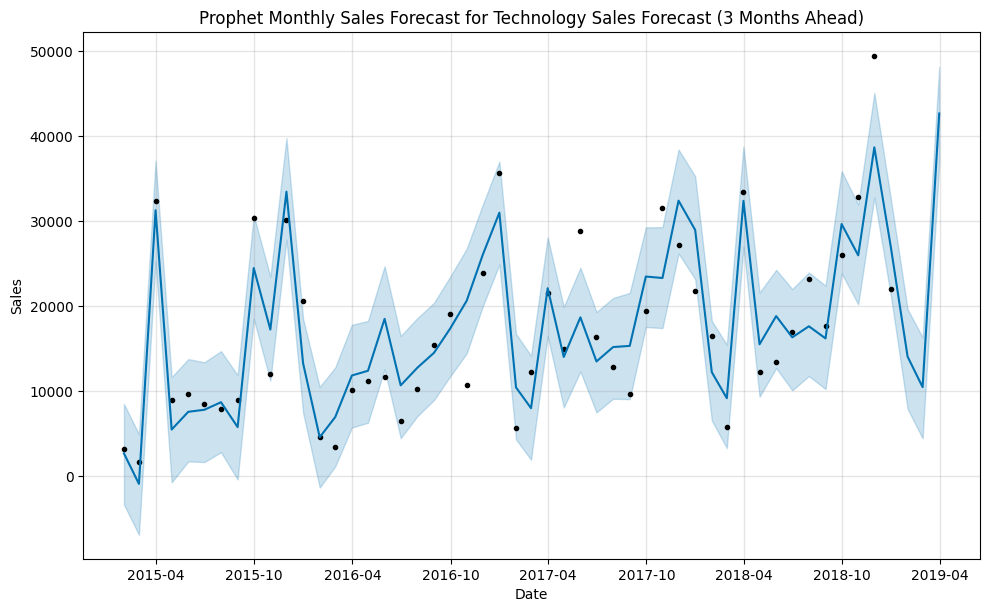

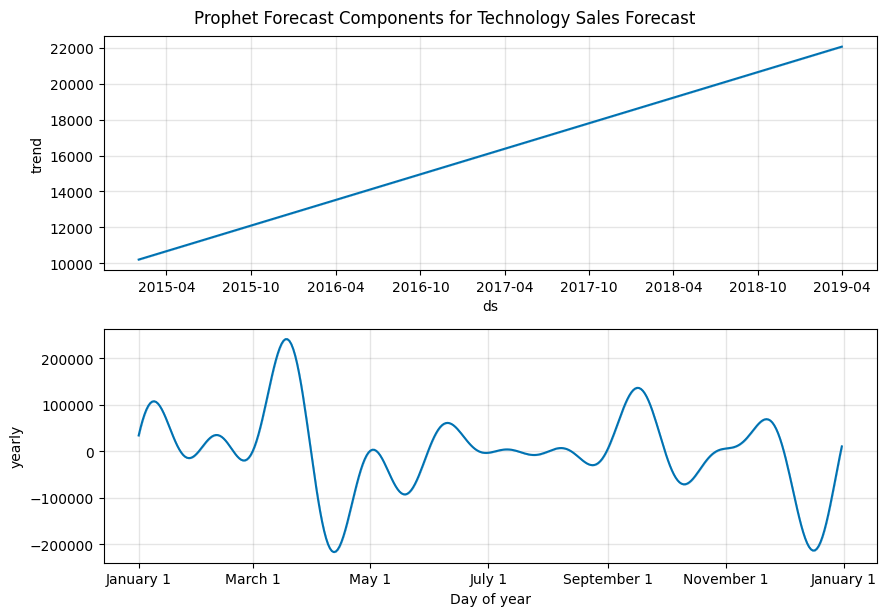

In [91]:
# 2. Technology Category sales
technology_forecast = forecast_segment_with_prophet(
    df[df["Category"]=="Technology"],
    "Technology Sales Forecast"
)

/tmp/ipykernel_690/954087241.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_segment_sales = segment_df.groupby(pd.Grouper(key="Order Date", freq="M")).agg({"Sales": "sum"}).reset_index()


Office Supplies Sales Forecast 3-Month Future Sales Forecast:


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,14646.724651,9397.142295,19930.873290
49,2019-02-28,12434.656284,7275.248429,17966.454305
50,2019-03-31,19698.155527,13996.845945,25196.919813


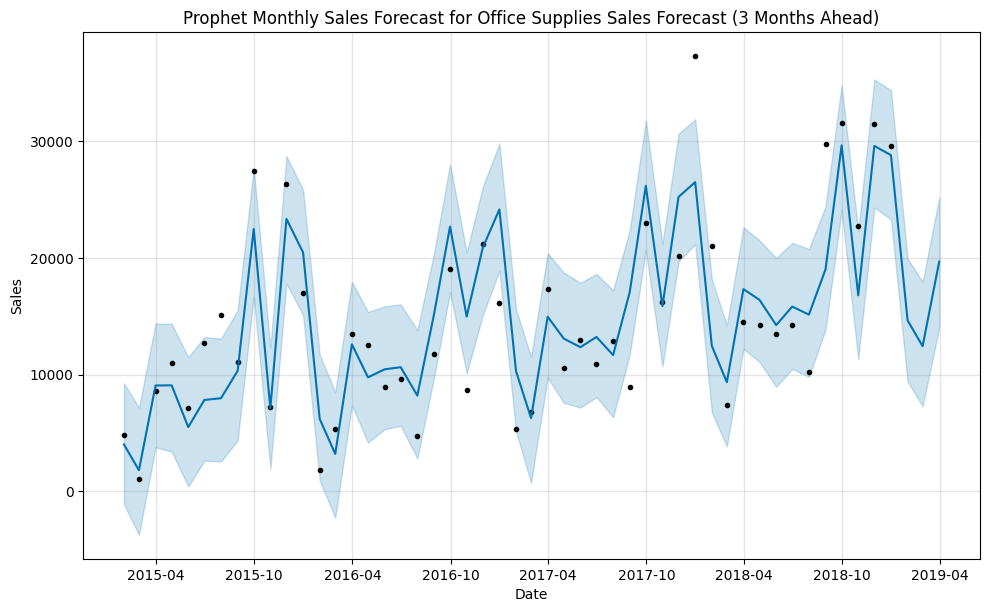

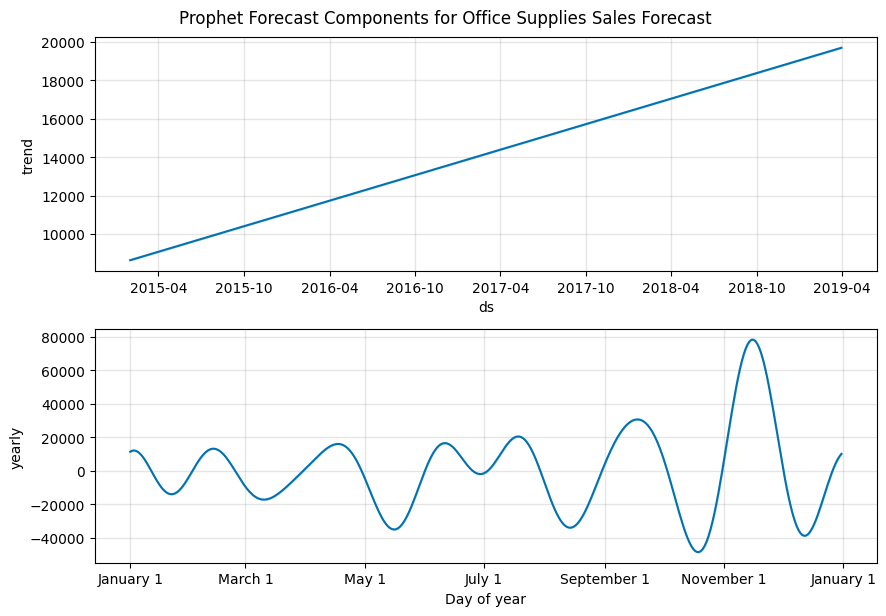

In [92]:
# 3. Office Supplies Category Sales
office_supplies_forecast = forecast_segment_with_prophet(
    df[df["Category"]=="Office Supplies"],
    "Office Supplies Sales Forecast"
)

#### Forecasting for Regions

/tmp/ipykernel_690/954087241.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_segment_sales = segment_df.groupby(pd.Grouper(key="Order Date", freq="M")).agg({"Sales": "sum"}).reset_index()


West Region Sales Forecast 3-Month Future Sales Forecast:


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,14048.800867,10326.492989,17491.468332
49,2019-02-28,11840.373145,8343.173631,15535.201048
50,2019-03-31,25805.336379,22016.424766,29328.364401


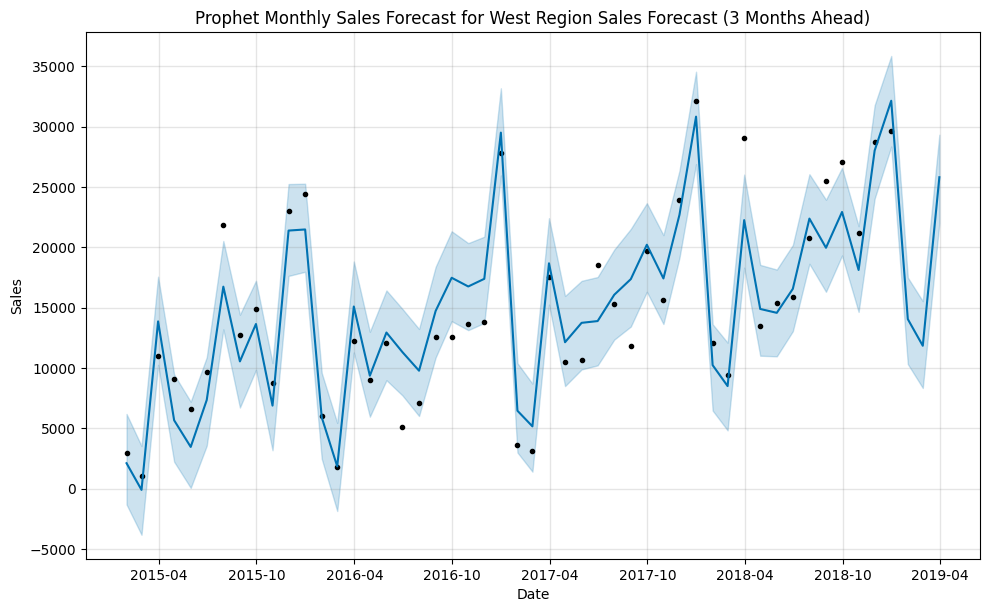

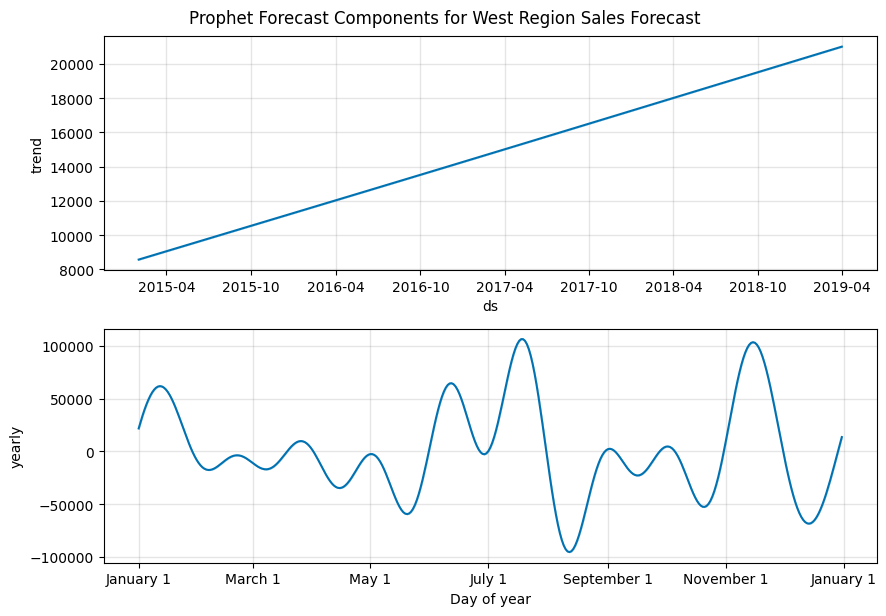

In [93]:
# 4. West Region Sales
west_region_forecast = forecast_segment_with_prophet(
    df[df['Region'] == 'West'],
    'West Region Sales Forecast'
)

/tmp/ipykernel_690/954087241.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_segment_sales = segment_df.groupby(pd.Grouper(key="Order Date", freq="M")).agg({"Sales": "sum"}).reset_index()
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


East Region Sales Forecast 3-Month Future Sales Forecast:


,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,9713.411357,3327.616793,16065.062493
49,2019-02-28,8120.218592,1861.935402,13859.110819
50,2019-03-31,15639.421337,9608.687347,21222.842716


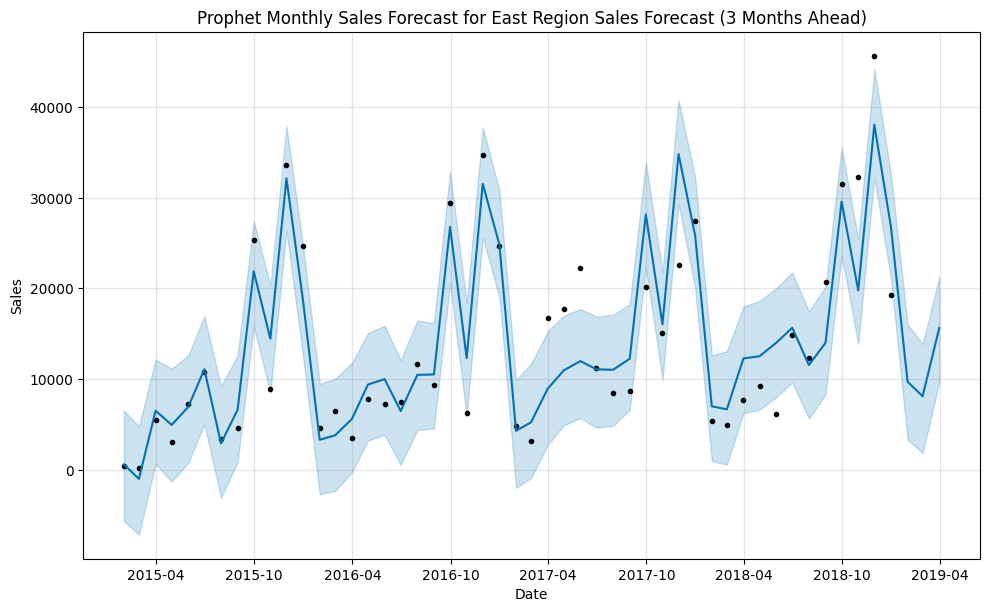

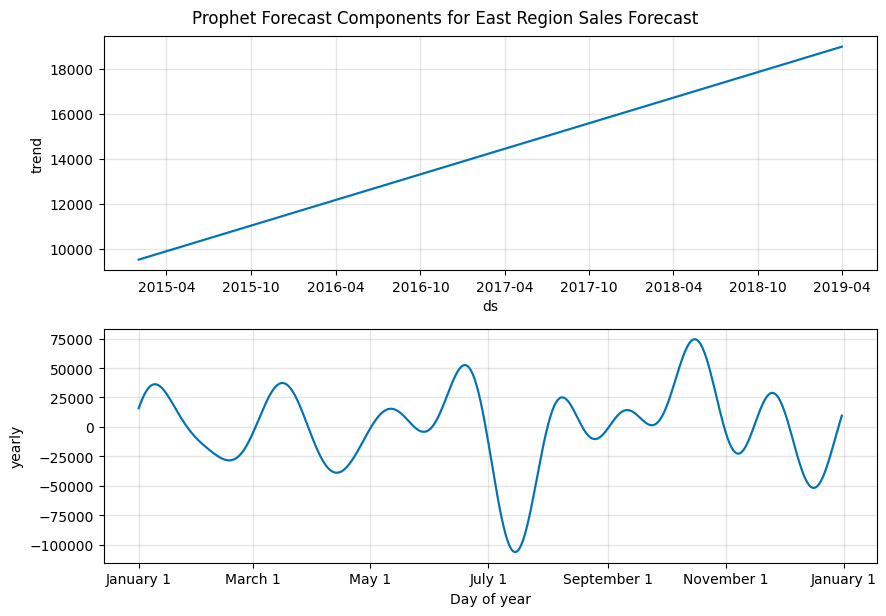

In [94]:
# 5. East Region Sales
east_region_forecast = forecast_segment_with_prophet(
    df[df['Region'] == 'East'],
    'East Region Sales Forecast'
)

### Combined Segment Forecasts Comparison

Combined Segment Forecasts (Jan-Mar 2019):


,ds,yhat,Segment
48,2019-01-31,9713.411357,East Region
48,2019-01-31,12691.392668,Furniture
48,2019-01-31,14646.724651,Office Supplies
48,2019-01-31,14033.343185,Technology
48,2019-01-31,14048.800867,West Region
49,2019-02-28,8120.218592,East Region
49,2019-02-28,6772.162417,Furniture
49,2019-02-28,12434.656284,Office Supplies
49,2019-02-28,10437.986784,Technology
49,2019-02-28,11840.373145,West Region


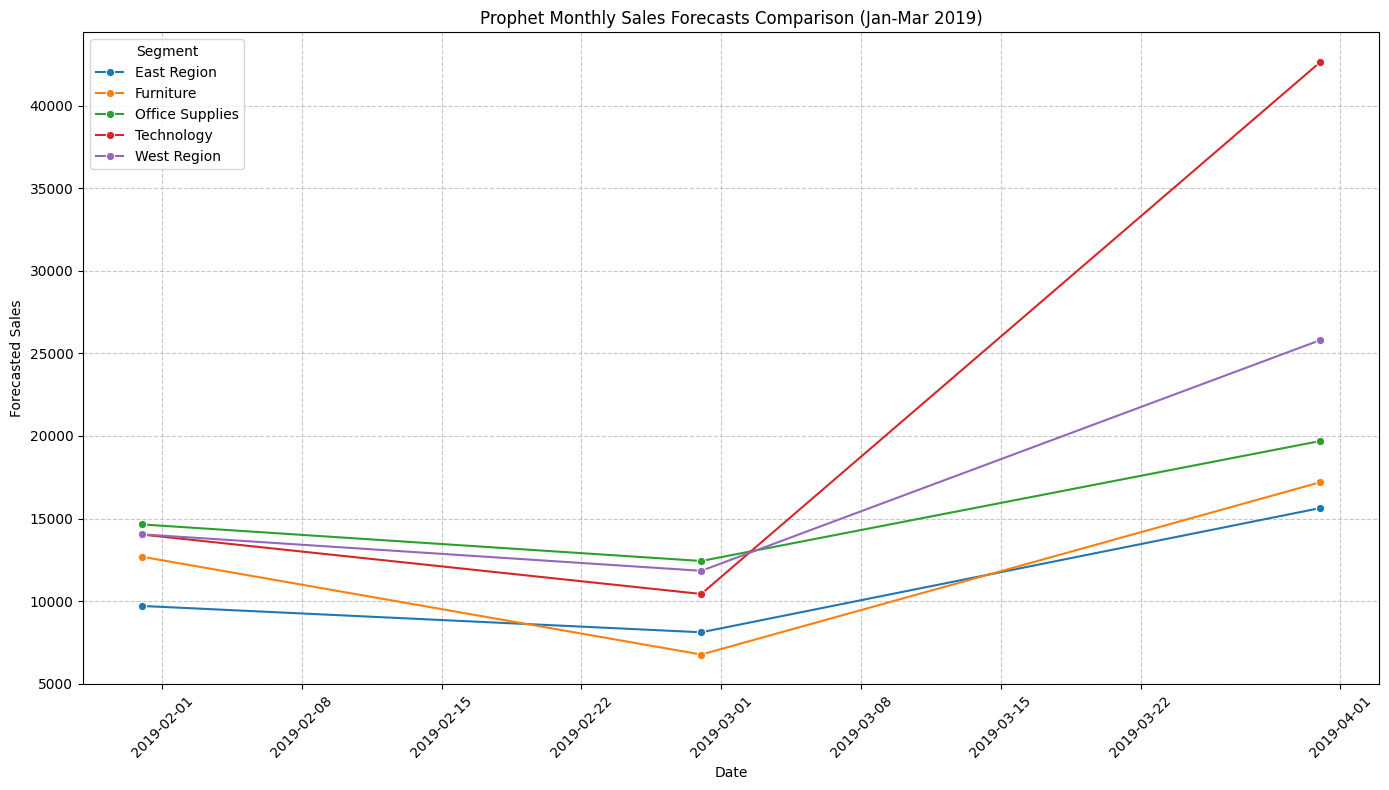

In [95]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Extract relevant forecast data (yhat for Jan, Feb, Mar 2019) for each segment
# Assuming these DataFrames are available from previous steps:
# furniture_forecast, technology_forecast, office_supplies_forecast, west_region_forecast, east_region_forecast

def get_future_yhat(forecast_df, segment_name):
    if forecast_df is None:
        return pd.DataFrame()
    # Filter for the last 3 months (Jan, Feb, Mar 2019 forecasts)
    future_forecast = forecast_df.tail(3)
    df_to_add = future_forecast[['ds', 'yhat']].copy()
    df_to_add['Segment'] = segment_name
    return df_to_add

# Collect forecasts for all segments
all_segments_forecasts = pd.concat([
    get_future_yhat(furniture_forecast, 'Furniture'),
    get_future_yhat(technology_forecast, 'Technology'),
    get_future_yhat(office_supplies_forecast, 'Office Supplies'),
    get_future_yhat(west_region_forecast, 'West Region'),
    get_future_yhat(east_region_forecast, 'East Region')
])

# Ensure 'ds' is datetime and sort
all_segments_forecasts['ds'] = pd.to_datetime(all_segments_forecasts['ds'])
all_segments_forecasts = all_segments_forecasts.sort_values(by=['ds', 'Segment'])

print("Combined Segment Forecasts (Jan-Mar 2019):")
display(all_segments_forecasts)

# Plotting the combined forecasts
plt.figure(figsize=(14, 8))
sns.lineplot(
    data=all_segments_forecasts,
    x='ds',
    y='yhat',
    hue='Segment',
    marker='o',
    palette='tab10'
)

plt.title('Prophet Monthly Sales Forecasts Comparison (Jan-Mar 2019)')
plt.xlabel('Date')
plt.ylabel('Forecasted Sales')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Segment')
plt.tight_layout()
plt.show()

**Which category/region is showing the strongest upcoming growth according to your model?**

In [96]:
# Assuming all_segments_forecasts is available in the environment
# Extract January and March 2019 forecasts for each segment
jan_forecasts = all_segments_forecasts[all_segments_forecasts['ds'].dt.month == 1].set_index('Segment')
mar_forecasts = all_segments_forecasts[all_segments_forecasts['ds'].dt.month == 3].set_index('Segment')

# Calculate growth for each segment
growth_analysis = pd.DataFrame({
    'Jan_yhat': jan_forecasts['yhat'],
    'Mar_yhat': mar_forecasts['yhat']
})

growth_analysis['Growth_Absolute'] = growth_analysis['Mar_yhat'] - growth_analysis['Jan_yhat']
growth_analysis['Growth_Percentage'] = (growth_analysis['Growth_Absolute'] / growth_analysis['Jan_yhat']) * 100

# Sort by percentage growth to find the strongest growth
strongest_growth = growth_analysis.sort_values(by='Growth_Percentage', ascending=False)

print("Segment-level Forecast Growth (Jan 2019 to Mar 2019):")
display(strongest_growth.round(2))

# Identify the segment with the highest percentage growth
top_segment = strongest_growth.iloc[0]
print(f"\nAccording to the Prophet model, **{top_segment.name}** is showing the strongest upcoming growth with a predicted sales increase of **{top_segment['Growth_Percentage']:.2f}%** from January to March 2019.")

Segment-level Forecast Growth (Jan 2019 to Mar 2019):


,Jan_yhat,Mar_yhat,Growth_Absolute,Growth_Percentage
Segment,,,,
Technology,14033.34,42639.49,28606.14,203.84
West Region,14048.80,25805.34,11756.54,83.68
East Region,9713.41,15639.42,5926.01,61.01
Furniture,12691.39,17201.02,4509.62,35.53
Office Supplies,14646.72,19698.16,5051.43,34.49



According to the Prophet model, **Technology** is showing the strongest upcoming growth with a predicted sales increase of **203.84%** from January to March 2019.


Based on the Prophet model's forecasts for January to March 2019, Technology is projected to have the strongest upcoming growth with a remarkable increase of 203.84%.

# TASK 5: Anomaly Detection in Sales Data

## Anomaly Detection Method 1: Isolation Forest

Isolation Forest is an unsupervised anomaly detection algorithm that identifies unusual observations by randomly partitioning the data. Since anomalies are few and different from the majority of the data, they are isolated in fewer splits than normal observations.

In [97]:
from sklearn.ensemble import IsolationForest

# Prepare the data for anomaly detection
# We'll use the 'Sales' column from weekly_sales
# Reshape to a 2D array as required by IsolationForest
weekly_sales_data = weekly_sales[['Sales']].copy()

# Initialize Isolation Forest model
# contamination: The proportion of outliers in the dataset. This is a crucial parameter.
# A value of 0.01 means we expect 1% of the data to be anomalies.
# Adjust this based on domain knowledge or initial exploration.
iso_forest = IsolationForest(random_state=42, contamination=0.01)

# Fit the model and predict anomalies
# The predict method returns -1 for anomalies and 1 for inliers
weekly_sales_data['anomaly'] = iso_forest.fit_predict(weekly_sales_data[['Sales']])

# Filter out the anomalous sales weeks
anomalies = weekly_sales_data[weekly_sales_data['anomaly'] == -1]

print("Identified Anomalous Sales Weeks:")
display(anomalies)

Identified Anomalous Sales Weeks:


,Sales,anomaly
7,224.912,-1
11,37703.665,-1
204,35998.900,-1


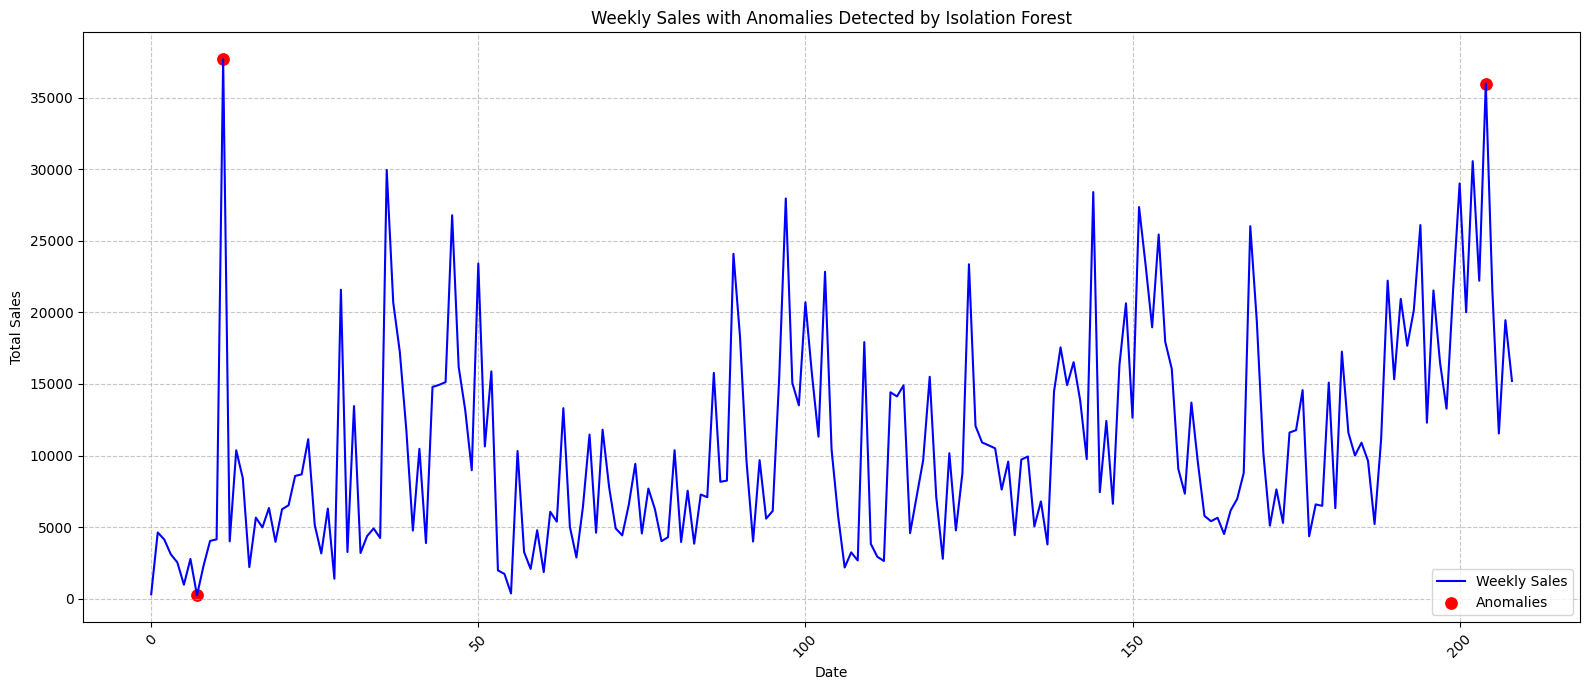

In [98]:
# Plotting weekly sales with anomalies highlighted
plt.figure(figsize=(16, 7))
sns.lineplot(x=weekly_sales.index, y=weekly_sales['Sales'], label='Weekly Sales', color='blue')
sns.scatterplot(x=anomalies.index, y=anomalies['Sales'], color='red', s=100, label='Anomalies', marker='o')

plt.title('Weekly Sales with Anomalies Detected by Isolation Forest')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Based on the anomaly detection, here are some possible real-world explanations for each anomalous sales week:

**Week 7 (Feb 22, 2015)** – Very Low Sales ($224.91): Sales were much lower than usual. This could be due to low customer demand, a store closure, or a data recording issue.

**Week 11 (Mar 22, 2015)** – Very High Sales ($37,703.67): Sales were unusually high, possibly because of a promotion, special event, or a large customer order.

**Week 204 (Dec 2, 2018)** – Very High Sales ($35,998.90): This spike was likely caused by the holiday shopping season, including Black Friday, Cyber Monday, or Christmas promotions.

## Anomaly Detection Method 2: Z-Score Based Detection

This method identifies sales weeks where the sales value deviates significantly from the average over a rolling window. A Z-score is calculated for each week, indicating how many standard deviations away from the rolling mean the sales value is. We will flag any week with an absolute Z-score greater than 2 as an anomaly.

In [99]:
# Calculate rolling mean and standard deviation for weekly sales
# A window of 4 weeks (approximately a month) is chosen for the rolling calculation
window_size = 4
weekly_sales['Rolling_Mean'] = weekly_sales['Sales'].rolling(window=window_size).mean()
weekly_sales['Rolling_Std'] = weekly_sales['Sales'].rolling(window=window_size).std()

# Calculate Z-Score
weekly_sales['Z_Score'] = (weekly_sales['Sales'] - weekly_sales['Rolling_Mean']) / weekly_sales['Rolling_Std']

# Identify anomalies: Z-score > 2 or Z-score < -2
zscore_anomalies = weekly_sales[
    (weekly_sales['Z_Score'] > 2) | (weekly_sales['Z_Score'] < -2)
].copy()

print("Identified Anomalous Sales Weeks using Z-Score:")
display(zscore_anomalies[['Order Date', 'Sales', 'Z_Score']])

Identified Anomalous Sales Weeks using Z-Score:


,Order Date,Sales,Z_Score


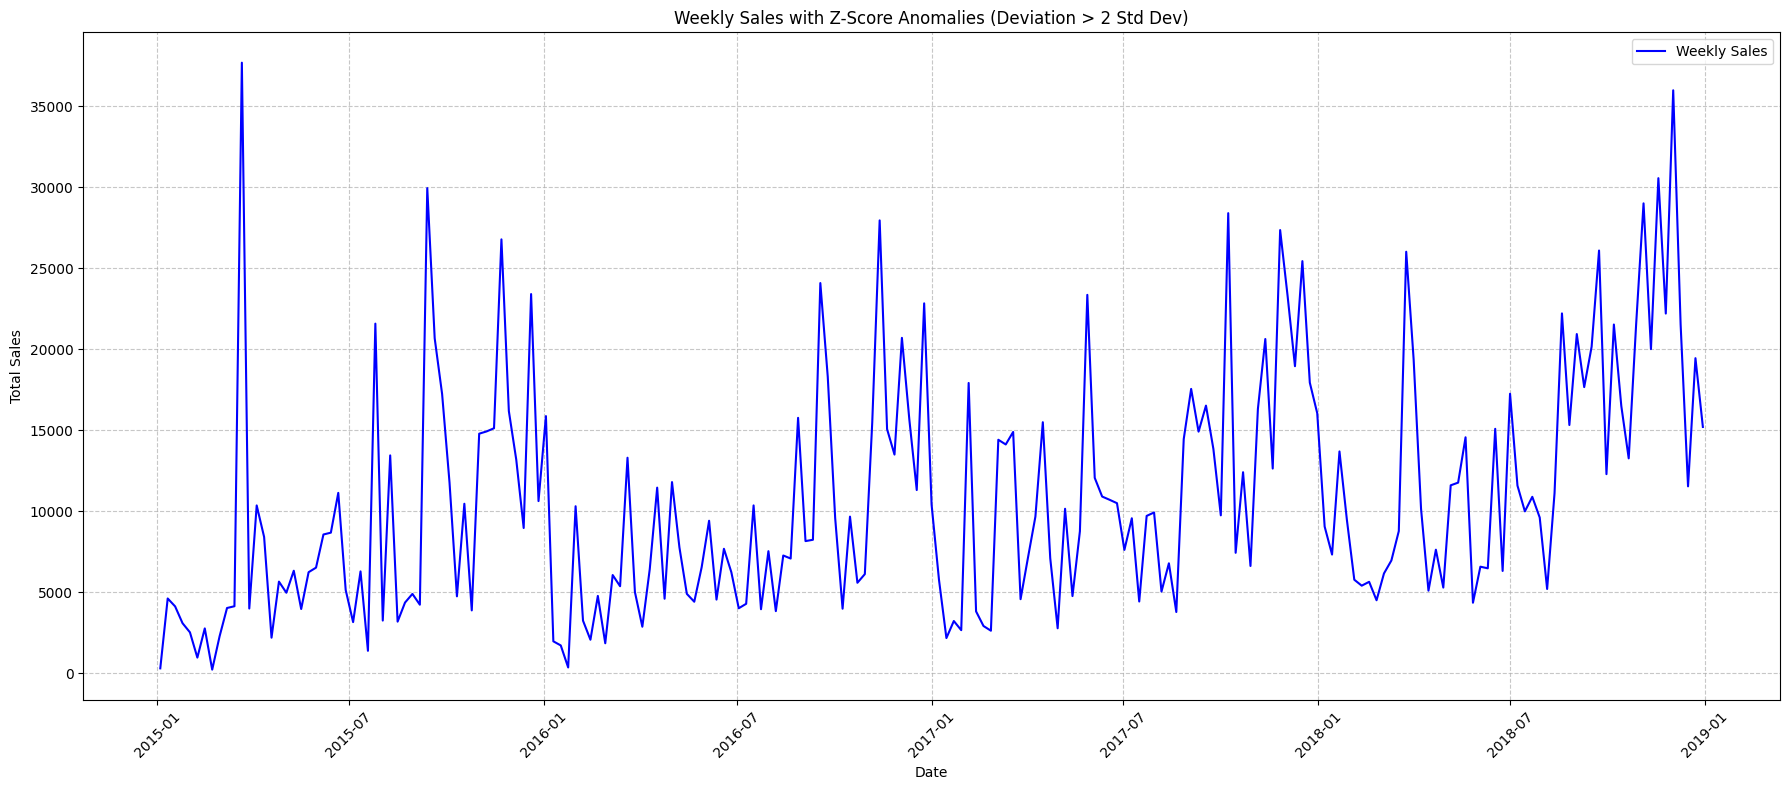

In [100]:
# Plotting weekly sales with Z-score anomalies highlighted
plt.figure(figsize=(18, 8))
sns.lineplot(x=weekly_sales['Order Date'], y=weekly_sales['Sales'], label='Weekly Sales', color='blue')
sns.scatterplot(
    x=zscore_anomalies['Order Date'],
    y=zscore_anomalies['Sales'],
    color='red',
    s=100,
    label='Z-Score Anomalies',
    marker='o'
)

plt.title('Weekly Sales with Z-Score Anomalies (Deviation > 2 Std Dev)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Inspecting Z-Score Calculation Details

Since no anomalies were identified with the current criteria, let's inspect the intermediate calculations (`Rolling_Mean`, `Rolling_Std`, and `Z_Score`) in the `weekly_sales` DataFrame. This will help us understand why no points crossed the 2 standard deviation threshold, and check for any data issues like `NaN` values in the initial rows due to the rolling window.

In [101]:
# Display the relevant columns to inspect the Z-score calculation
display(weekly_sales[['Order Date', 'Sales', 'Rolling_Mean', 'Rolling_Std', 'Z_Score']].head(10))
display(weekly_sales[['Order Date', 'Sales', 'Rolling_Mean', 'Rolling_Std', 'Z_Score']].tail(10))

,Order Date,Sales,Rolling_Mean,Rolling_Std,Z_Score
0,2015-01-04,304.508,NaN,NaN,NaN
1,2015-01-11,4619.108,NaN,NaN,NaN
2,2015-01-18,4130.533,NaN,NaN,NaN
3,2015-01-25,3092.544,3036.67325,1929.462566,0.028957
4,2015-02-01,2527.914,3592.52475,953.362968,-1.116690
5,2015-02-08,968.534,2679.88125,1319.909656,-1.296564
6,2015-02-15,2771.054,2340.01150,943.108457,0.457044
7,2015-02-22,224.912,1623.10350,1227.446277,-1.139106
8,2015-03-01,2289.643,1563.53575,1173.495162,0.618756
9,2015-03-08,4030.728,2329.08425,1583.248262,1.074780


,Order Date,Sales,Rolling_Mean,Rolling_Std,Z_Score
199,2018-10-28,21535.2700,18212.87830,4058.039525,0.818718
200,2018-11-04,29017.4670,20083.34655,6858.258910,1.302681
201,2018-11-11,20015.5500,20959.77630,6461.919539,-0.146122
202,2018-11-18,30572.4470,25285.18350,5282.549382,1.000892
203,2018-11-25,22212.7690,25454.55825,5130.922994,-0.631814
204,2018-12-02,35998.9000,27199.91650,7422.552005,1.185439
205,2018-12-09,21537.2410,27580.33925,6955.926028,-0.868770
206,2018-12-16,11542.8340,22822.93600,10047.753378,-1.122649
207,2018-12-23,19457.0680,22134.01075,10196.900436,-0.262525
208,2018-12-30,15210.8858,16937.00720,4456.809660,-0.387300


**Compare: do both methods flag the same anomalies, or do they disagree? What does this tell you?**

Isolation Forest detected 3 anomalies:
Week 7: Unusually low sales.
Weeks 11 and 204: Unusually high sales.
Z-Score detected no anomalies because none of the sales values were more than 2 standard deviations away from the 4-week rolling average.
This means the Z-Score method is less sensitive than Isolation Forest with the current settings.

To detect more anomalies using Z-Score, we can:

Lower the threshold (e.g., from 2 to 1.5 or 1).
Use a smaller rolling window so the method responds more quickly to changes in sales.

# TASK 6: Product Demand Segmentation using Clustering

**Aggregate data at the product sub-category level with features like:**

Total sales volume

In [102]:
sub_category_sales = df.groupby('Sub-Category')['Sales'].sum().reset_index()
sub_category_sales.rename(columns={'Sales': 'Total Sales Volume'}, inplace=True)

print("Total Sales Volume by Product Sub-Category:")
display(sub_category_sales.head())

Total Sales Volume by Product Sub-Category:


,Sub-Category,Total Sales Volume
0,Accessories,164186.7000
1,Appliances,104618.4030
2,Art,26705.4100
3,Binders,200028.7850
4,Bookcases,113813.1987


Sales growth rate (year-over-year)

In [103]:
sub_category_annual_sales = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().reset_index()

# Calculate Year-over-Year Growth Rate
sub_category_annual_sales['YoY_Growth'] = sub_category_annual_sales.groupby('Sub-Category')['Sales'].pct_change() * 100

print("Sales Growth Rate (Year-over-Year) by Product Sub-Category:")
display(sub_category_annual_sales.head())

Sales Growth Rate (Year-over-Year) by Product Sub-Category:


,Sub-Category,Year,Sales,YoY_Growth
0,Accessories,2015,23766.396,NaN
1,Accessories,2016,40443.970,70.172920
2,Accessories,2017,41735.364,3.193045
3,Accessories,2018,58240.970,39.548250
4,Appliances,2015,15160.715,NaN


Sales volatility (standard deviation of monthly sales)

In [105]:
# Calculate monthly sales per sub-category to find volatility
sub_cat_monthly_sales = df.groupby(['Sub-Category', 'Year', 'Month'])['Sales'].sum().reset_index()

# Calculate the standard deviation (volatility) for each Sub-Category
sub_category_volatility = sub_cat_monthly_sales.groupby('Sub-Category')['Sales'].std().reset_index()
sub_category_volatility.rename(columns={'Sales': 'Sales Volatility (Std Dev)'}, inplace=True)

# Calculate final metrics for the summary table
# 1. Total Sales per Sub-Category
final_sub_cat_summary = df.groupby('Sub-Category')['Sales'].sum().reset_index()
final_sub_cat_summary.rename(columns={'Sales': 'Total Sales Volume'}, inplace=True)

# 2. Latest YoY Growth (from 2018)
latest_yoy = sub_category_annual_sales[sub_category_annual_sales['Year'] == 2018][['Sub-Category', 'YoY_Growth']]

# Merge all metrics into one summary DataFrame
segmentation_summary = final_sub_cat_summary.merge(latest_yoy, on='Sub-Category')
segmentation_summary = segmentation_summary.merge(sub_category_volatility, on='Sub-Category')

print("Product Sub-Category Segmentation Summary:")
display(segmentation_summary.sort_values(by='Total Sales Volume', ascending=False))

Product Sub-Category Segmentation Summary:


,Sub-Category,Total Sales Volume,YoY_Growth,Sales Volatility (Std Dev)
13,Phones,327782.4480,34.212004,4052.718221
5,Chairs,322822.7310,13.744514,4407.232960
14,Storage,219343.3920,15.864571,2822.084310
16,Tables,202810.6280,0.216303,3224.082504
3,Binders,200028.7850,46.386288,3848.223648
11,Machines,189238.6310,-22.112144,5603.554747
0,Accessories,164186.7000,39.548250,2579.994809
6,Copiers,146248.0940,35.794694,5500.774391
4,Bookcases,113813.1987,14.267352,2220.405080
1,Appliances,104618.4030,54.564520,1821.621539


Average order value

In [106]:
import pandas as pd

# Calculate Average Order Value (AOV) per sub-category
# Formula: Total Sales / Number of Unique Orders
sub_cat_aov = df.groupby('Sub-Category').agg({
    'Sales': 'sum',
    'Order ID': 'nunique'
}).reset_index()

sub_cat_aov['Average Order Value'] = sub_cat_aov['Sales'] / sub_cat_aov['Order ID']

# Keep only necessary columns for merging
sub_cat_aov = sub_cat_aov[['Sub-Category', 'Average Order Value']]

# Merge into the segmentation_summary
segmentation_summary = segmentation_summary.merge(sub_cat_aov, on='Sub-Category')

print("Enriched Product Sub-Category Segmentation Summary (with AOV):")
display(segmentation_summary.sort_values(by='Total Sales Volume', ascending=False).round(2))

Enriched Product Sub-Category Segmentation Summary (with AOV):


,Sub-Category,Total Sales Volume,YoY_Growth,Sales Volatility (Std Dev),Average Order Value
13,Phones,327782.45,34.21,4052.72,408.20
5,Chairs,322822.73,13.74,4407.23,570.36
14,Storage,219343.39,15.86,2822.08,287.10
16,Tables,202810.63,0.22,3224.08,671.56
3,Binders,200028.78,46.39,3848.22,154.94
11,Machines,189238.63,-22.11,5603.55,1689.63
0,Accessories,164186.70,39.55,2579.99,233.88
6,Copiers,146248.09,35.79,5500.77,2215.88
4,Bookcases,113813.20,14.27,2220.41,512.67
1,Appliances,104618.40,54.56,1821.62,235.63


### Preparing Data and Determining Optimal Clusters
We will use the quantitative metrics (Volume, Growth, Volatility, AOV) for clustering. We'll start by scaling the data and using the Elbow Method.

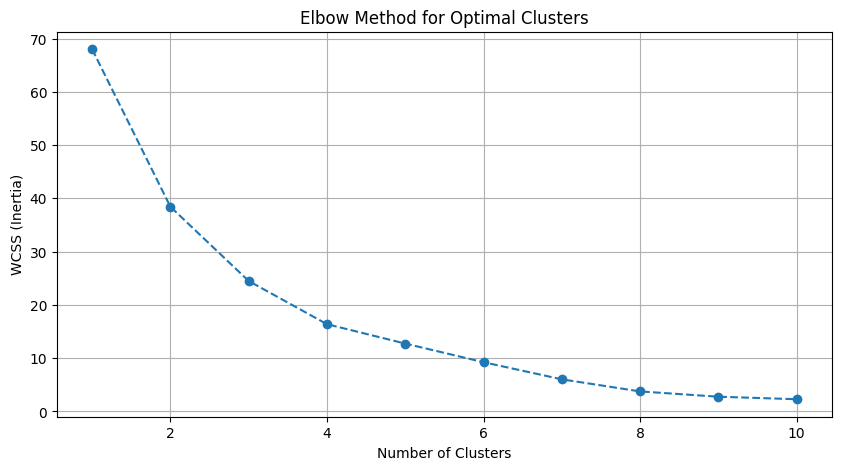

In [107]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features for clustering
features = ['Total Sales Volume', 'YoY_Growth', 'Sales Volatility (Std Dev)', 'Average Order Value']
X_cluster = segmentation_summary[features]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Determine optimal K using the Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

### Applying K-Means Clustering
Based on the elbow plot, we will select an appropriate number of clusters (typically 3 or 4 for retail segmentation) and assign labels to our sub-categories.

,Sub-Category,Total Sales Volume,YoY_Growth,Sales Volatility (Std Dev),Average Order Value,Cluster
1,Appliances,104618.4030,54.564520,1821.621539,235.627034,0
2,Art,26705.4100,49.825485,330.488343,37.090847,0
12,Paper,76828.3040,35.317901,1024.824982,66.060451,0
10,Labels,12347.7260,37.671467,223.471218,36.316841,0
5,Chairs,322822.7310,13.744514,4407.232960,570.358182,1
13,Phones,327782.4480,34.212004,4052.718221,408.197320,1
0,Accessories,164186.7000,39.548250,2579.994809,233.884188,1
3,Binders,200028.7850,46.386288,3848.223648,154.940964,1
14,Storage,219343.3920,15.864571,2822.084310,287.098681,1
16,Tables,202810.6280,0.216303,3224.082504,671.558371,1


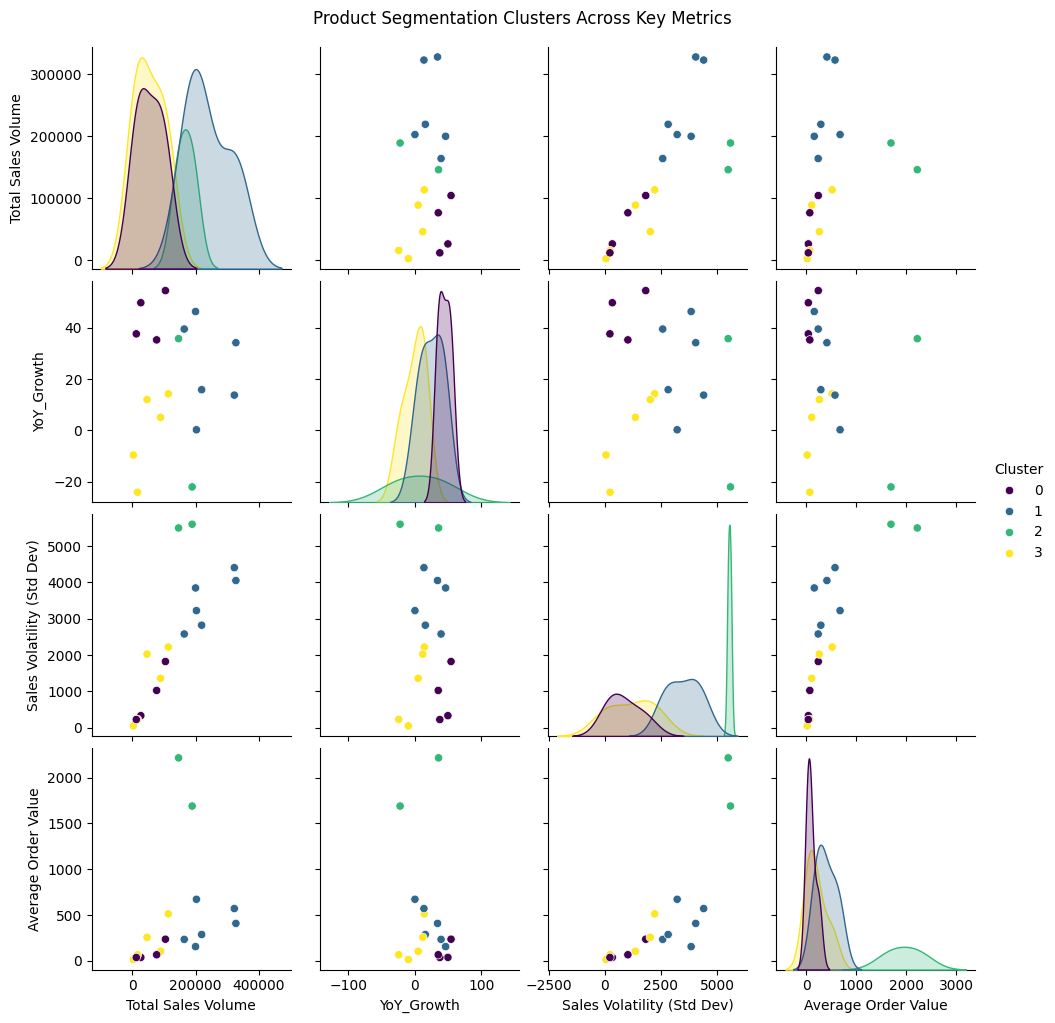

In [108]:
# Applying K-Means (Choosing K=4 based on standard retail strategy splits)
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
segmentation_summary['Cluster'] = kmeans.fit_predict(X_scaled)

# Map clusters to descriptive names based on their profiles
# Note: Profile analysis usually follows, but we'll display the numeric labels first
display(segmentation_summary.sort_values(by='Cluster'))

# Visualize the clusters using a Pair Plot to see relationships
sns.pairplot(segmentation_summary, vars=features, hue='Cluster', palette='viridis')
plt.suptitle('Product Segmentation Clusters Across Key Metrics', y=1.02)
plt.show()

In [110]:
# Analyze the average metrics for each cluster to define profiles
cluster_profiles = segmentation_summary.groupby('Cluster')[features].mean().round(2)
cluster_counts = segmentation_summary.groupby('Cluster').size().to_frame(name='Count')
cluster_profiles = cluster_profiles.join(cluster_counts)

print("Cluster Profile Averages:")
display(cluster_profiles)

# List sub-categories within each cluster for qualitative validation
for cluster_id in sorted(segmentation_summary['Cluster'].unique()):
    sub_cats = segmentation_summary[segmentation_summary['Cluster'] == cluster_id]['Sub-Category'].tolist()
    print(f"\nCluster {cluster_id} Sub-Categories: {', '.join(sub_cats)}")

Cluster Profile Averages:


,Total Sales Volume,YoY_Growth,Sales Volatility (Std Dev),Average Order Value,Count
Cluster,,,,,
0,55124.96,44.34,850.10,93.77,4
1,239495.78,25.00,3489.06,387.67,6
2,167743.36,6.84,5552.16,1952.76,2
3,53715.11,-0.50,1176.50,190.80,5



Cluster 0 Sub-Categories: Appliances, Art, Labels, Paper

Cluster 1 Sub-Categories: Accessories, Binders, Chairs, Phones, Storage, Tables

Cluster 2 Sub-Categories: Copiers, Machines

Cluster 3 Sub-Categories: Bookcases, Envelopes, Fasteners, Furnishings, Supplies


In [112]:
# Define descriptive labels based on the profile analysis
cluster_map = {
    0: 'Growing Demand',
    1: 'High-Volume, Stable Demand',
    2: 'Low Volume, High Volatility',
    3: 'Declining Demand'
}

# Apply labels to the summary
segmentation_summary['Demand Group'] = segmentation_summary['Cluster'].map(cluster_map)

# Finalized Segmentation Table
print('Final Product Demand Segmentation:')
display(segmentation_summary[['Sub-Category', 'Demand Group', 'Total Sales Volume', 'YoY_Growth', 'Average Order Value']].sort_values(by='Demand Group'))

Final Product Demand Segmentation:


,Sub-Category,Demand Group,Total Sales Volume,YoY_Growth,Average Order Value
8,Fasteners,Declining Demand,3001.9600,-9.637800,14.160189
4,Bookcases,Declining Demand,113813.1987,14.267352,512.672066
7,Envelopes,Declining Demand,16128.0460,-24.190516,66.370560
15,Supplies,Declining Demand,46420.3080,12.007073,256.465790
9,Furnishings,Declining Demand,89212.0180,5.064519,104.341542
1,Appliances,Growing Demand,104618.4030,54.564520,235.627034
2,Art,Growing Demand,26705.4100,49.825485,37.090847
12,Paper,Growing Demand,76828.3040,35.317901,66.060451
10,Labels,Growing Demand,12347.7260,37.671467,36.316841
14,Storage,"High-Volume, Stable Demand",219343.3920,15.864571,287.098681


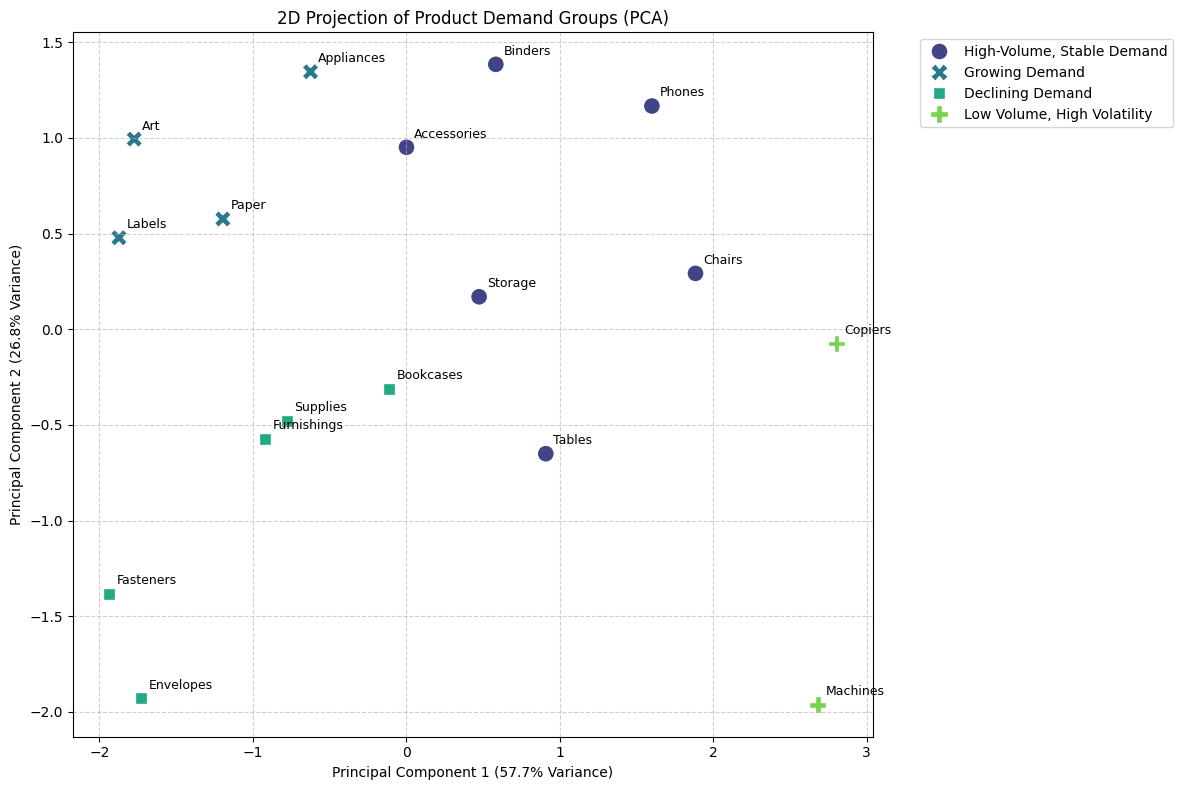

In [113]:
from sklearn.decomposition import PCA

# Initialize PCA to reduce to 2 components
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_scaled)

# Add PCA results to the summary dataframe
segmentation_summary['PCA1'] = pca_results[:, 0]
segmentation_summary['PCA2'] = pca_results[:, 1]

# Plot the 2D clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Demand Group',
    style='Demand Group',
    data=segmentation_summary,
    s=150,
    palette='viridis'
)

# Annotate the points with sub-category names
for i in range(segmentation_summary.shape[0]):
    plt.text(
        segmentation_summary.PCA1[i] + 0.05,
        segmentation_summary.PCA2[i] + 0.05,
        segmentation_summary['Sub-Category'][i],
        fontsize=9
    )

plt.title('2D Projection of Product Demand Groups (PCA)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} Variance)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

 What stocking strategy would you recommend for each cluster?

Based on the performance metrics of each cluster, here are the recommended stocking strategies:

1. **High-Volume, Stable Demand** (Phones, Chairs, Storage, Binders, Accessories, Tables)
Strategy: Just-in-Time (JIT) & Lean Replenishment.
Why: These products have consistent sales and high volume. You can afford to keep high stock levels because the risk of 'dead stock' is low, but you should use automated replenishment to minimize holding costs.
Action: Maintain high service levels (e.g., 98% availability) to avoid losing revenue on these bread-and-butter items.

2. **Growing Demand** (Appliances, Art, Labels, Paper)
Strategy: Aggressive Growth Stocking.
Why: These categories are showing strong positive momentum (High YoY Growth). Historical averages will likely under-calculate the stock needed.
Action: Increase safety stock levels ahead of the projected growth to capture market share and prevent stockouts during demand surges.

3. **Low Volume, High Volatility** (Copiers, Machines)
Strategy: Make-to-Order or Low Inventory (Dropship).
Why: These items have a very high Average Order Value (AOV) but infrequent, unpredictable sales. Keeping these in a warehouse is a massive drain on capital.
Action: Treat these as specialty items. Keep minimal local inventory and rely on fast-ship agreements with suppliers or dropshipping directly to customers.

4. **Declining Demand** (Bookcases, Envelopes, Fasteners, Furnishings, Supplies)
Strategy: Inventory Liquidation & Clearance.
Why: These items show negative or stagnant growth. Every month they sit on the shelf, they lose value.
Action: Do not restock these items in bulk. Use promotional bundles (e.g., 'Buy a Desk, get Fasteners free') to clear the remaining stock and reallocate that warehouse space to the 'Growing Demand' cluster.